# Credit Card Transactions — PySpark Ingestion, Cleaning & Analysis

**Data engineering assessment.** This notebook reads a messy, nested JSON feed of credit-card
transactions with PySpark, flattens it to the required tabular schema, cleans it, protects the
personal data in it, and then looks for something worth knowing.

The four things the brief asks to be explained explicitly are answered in their own sections:

| Requirement | Section |
|---|---|
| **JSON flattening** to the 26 expected columns | §2 |
| **Data quality** — how dirty data is found and handled | §4 |
| **Timestamp conversion** to UTC+8, `YYYY-MM-DD HH:MM:SS.SSSSSS Z` | §4.1 |
| **Name derivation** from `person_name` | §4.2 |
| **PII handling** | §5 |
| **Visualisation & insight** | §7 |

### The stance this notebook takes

Three decisions shape everything below, so they are worth stating up front.

**Nothing is silently dropped.** Every record that fails a rule is *tagged* with the rule it
failed and routed to a quarantine table, not deleted. A pipeline that quietly discards 4% of its
input is a pipeline that will one day quietly discard 40% of it. The quarantine table is a
first-class output.

**Types are never inferred.** The file is read with every leaf forced to `string`, and each column
is then cast deliberately with an explicit failure path. Letting Spark infer types on dirty data
means Spark decides what to null out, and it does so without telling you.

**PII is handled in layers, not in one pass.** The raw layer keeps everything, the curated layer
replaces identifiers with keyed tokens, and the analytics layer generalises the quasi-identifiers
that make re-identification possible. Only the last one is meant to be widely readable.


---
## 0. Environment

Spark runs in local mode inside the container. Two configuration choices matter for correctness
rather than performance:

`spark.sql.session.timeZone = UTC` — the source encodes time in at least five different ways, some
of which are naive strings with no offset. Pinning the session to UTC means a naive string is
interpreted as UTC rather than as "whatever the container's clock happens to be set to", which
would make the output depend on where the notebook is run. The UTC+8 conversion the brief asks for
then happens explicitly, once, at the end of the parsing chain.

`spark.sql.ansi.enabled = false` (the default) — a failed `cast` yields `NULL` rather than throwing.
That is what makes "cast, then check what became null" a usable validation strategy.

`spark.sql.legacy.timeParserPolicy = CORRECTED` — this one is not optional, and it is easy to get
wrong. Under Spark 3's **default** `EXCEPTION` policy, `to_timestamp("1994-05-04 00:00:00",
"yyyy-MM-dd")` does not return `NULL`; it **throws** and kills the job, because the string partially
matches and Spark refuses to guess. That makes the "try several formats and `coalesce`" strategy in
§4.1 impossible — the first non-matching candidate aborts the query. `CORRECTED` restores
`NULL`-on-failure with the ISO-8601-correct parser, which is what the coalesce chain needs.
(`LEGACY` would also return `NULL`, but it brings back the lenient pre-3.0 parser, which happily
accepts genuinely malformed dates — the opposite of what a cleaning pipeline wants.)


In [1]:
import os
import json
import hashlib
import hmac as hmac_lib
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T

# Installed as an editable package from pyproject.toml, so this is a normal
# import rather than a sys.path fixup.
from paynet_iv import viz_theme as vz

vz.apply_theme()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

spark = (
    SparkSession.builder
    .appName("paynet-iv-credit-card-transactions")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.legacy.timeParserPolicy", "CORRECTED")
    # Progress bars are written to stderr and interleave into every cell's
    # output, which makes the notebook unreadable once it is committed.
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# The dq_flags expression in §4.7 is ~40 CASE WHENs wide, which pushes Spark's
# whole-stage codegen past the JVM's hard 64 KB method limit. Spark handles this
# correctly by falling back to the interpreted path -- but it logs a full stack
# trace while doing so, which buries the actual cell output. Silence that one
# logger rather than the whole category.
try:
    _jvm = spark.sparkContext._jvm
    _jvm.org.apache.logging.log4j.core.config.Configurator.setLevel(
        "org.apache.spark.sql.catalyst.expressions.codegen.CodeGenerator",
        _jvm.org.apache.logging.log4j.Level.FATAL,
    )
except Exception as exc:                      # different log backend -- not fatal
    print(f"(could not adjust codegen logger: {exc})")

RAW_PATH = "../data/raw/transactions.json"
CURATED_DIR = "../data/curated"
DISPLAY_TZ = "Asia/Singapore"   # UTC+8, and — importantly — no daylight saving
TS_FORMAT = "yyyy-MM-dd HH:mm:ss.SSSSSS"

print(f"Spark {spark.version} | session tz = {spark.conf.get('spark.sql.session.timeZone')}")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/22 03:15:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.3 | session tz = UTC


---
## 1. Ingestion

### 1.1 Read everything as text first

The instinct is `spark.read.json(path)` and move on. That is a mistake on a feed like this one.
Schema inference scans the data, picks a type per field, and then *applies* it — so `"$1,204.50"`
in a column Spark decided was `double` becomes `NULL` before any code of mine runs. The corruption
is invisible: the column looks clean, it is just missing values.

So the read happens in two passes:

1. **Infer the structure** — purely to learn the nesting, not the types.
2. **Rewrite that structure with every leaf as `string`** and re-read with it supplied explicitly.

This keeps the shape (which can be arbitrarily nested and is not known in advance) while giving up
none of the control over types. Every value arrives exactly as it was written, and every
subsequent `NULL` is one this notebook created on purpose.

`mode=PERMISSIVE` with a `_corrupt_record` column catches lines that are not valid JSON at all —
those cannot be parsed into *any* schema and would otherwise abort the read.


In [2]:
# Pass 1 — learn the structure only.
inferred_schema = (
    spark.read
    .option("mode", "PERMISSIVE")
    .option("columnNameOfCorruptRecord", "_corrupt_record")
    .json(RAW_PATH)
    .schema
)

print("Inferred structure (types here are discarded — only the shape is kept):")
print(inferred_schema.simpleString()[:1200], "...")


Inferred structure (types here are discarded — only the shape is kept):
struct<Unnamed: 0:bigint,_corrupt_record:string,amt:string,category:string,cc_bic:string,cc_num:string,is_fraud:string,merch_eff_time:string,merch_last_update_time:string,merch_lat:double,merch_long:double,merch_zipcode:string,merchant:string,personal_detail:struct<address:struct<city:string,state:string,street:string,zip:string>,city_pop:bigint,dob:string,gender:string,job:string,lat:string,long:string,person_name:string>,trans_date_trans_time:string,trans_num:string> ...


In [3]:
def stringify_schema(dtype):
    # Walk the inferred schema and replace every leaf type with StringType,
    # leaving the struct/array/map skeleton intact. Recursion handles nesting
    # of any depth, so this does not need to know the feed's layout.
    if isinstance(dtype, T.StructType):
        return T.StructType([
            T.StructField(f.name, stringify_schema(f.dataType), nullable=True)
            for f in dtype.fields
        ])
    if isinstance(dtype, T.ArrayType):
        return T.ArrayType(stringify_schema(dtype.elementType), containsNull=True)
    if isinstance(dtype, T.MapType):
        return T.MapType(T.StringType(), stringify_schema(dtype.valueType), True)
    return T.StringType()


string_schema = stringify_schema(inferred_schema)

# PERMISSIVE mode only populates _corrupt_record if the column is declared.
if "_corrupt_record" not in string_schema.fieldNames():
    string_schema = string_schema.add(T.StructField("_corrupt_record", T.StringType(), True))

# Pass 2 — the real read.
raw_df = (
    spark.read
    .option("mode", "PERMISSIVE")
    .option("columnNameOfCorruptRecord", "_corrupt_record")
    .schema(string_schema)
    .json(RAW_PATH)
)

# Spark refuses to filter a JSON source on _corrupt_record alone unless the
# frame is materialised first — this cache is load-bearing, not an optimisation.
raw_df = raw_df.cache()

total_lines = raw_df.count()
corrupt_df = raw_df.filter(F.col("_corrupt_record").isNotNull())
n_corrupt = corrupt_df.count()

print(f"lines read      : {total_lines:,}")
print(f"unparseable JSON: {n_corrupt:,}  ({n_corrupt / total_lines:.3%})")
if n_corrupt:
    print("\nexamples:")
    for r in corrupt_df.select("_corrupt_record").limit(3).collect():
        print("   ", r[0][:110])


lines read      : 40,642
unparseable JSON: 2  (0.005%)

examples:
    {"Unnamed: 0": 999999, "cc_num": , "amt": }
    {not json at all}


In [4]:
# The structurally broken lines are the first quarantine bucket. They are kept,
# not discarded — an operator needs to see them to fix the upstream producer.
quarantine_corrupt = corrupt_df.select(
    F.col("_corrupt_record").alias("raw_line"),
    F.lit("PARSE_FAILURE").alias("reject_reason"),
)

parsed_df = raw_df.filter(F.col("_corrupt_record").isNull()).drop("_corrupt_record")
print(f"rows carried forward: {parsed_df.count():,}")


rows carried forward: 40,640


---
## 2. JSON flattening

The feed nests the cardholder under `personal_detail`, with the address nested again below that.
The brief wants a flat table of 26 named columns.

Rather than hand-write `col("personal_detail.address.zip").alias("zip")` twenty times, §2.1 uses a
**generic flattener**: it repeatedly expands any struct-typed column into its children until no
structs remain. This costs nothing extra to write and is robust to the producer moving a field
between nesting levels — a very common source of breakage in JSON feeds.

§2.2 then maps the flattened names onto the required output names by **leaf name**, so
`personal_detail.address.zip` resolves to `zip` regardless of the path it arrived on.


In [5]:
def flatten_structs(df, sep="."):
    # Iteratively expand struct columns. Each pass promotes one level of
    # nesting; the loop ends when the schema is flat.
    while True:
        struct_fields = [
            f.name for f in df.schema.fields if isinstance(f.dataType, T.StructType)
        ]
        if not struct_fields:
            return df

        projection = []
        for f in df.schema.fields:
            if f.name in struct_fields:
                for child in f.dataType.fields:
                    projection.append(
                        F.col(f"`{f.name}`.`{child.name}`").alias(f"{f.name}{sep}{child.name}")
                    )
            else:
                projection.append(F.col(f"`{f.name}`"))
        df = df.select(projection)


flat_df = flatten_structs(parsed_df)

print(f"{len(parsed_df.columns)} top-level columns -> {len(flat_df.columns)} flat columns\n")
for c in flat_df.columns:
    print("  ", c)


15 top-level columns -> 25 flat columns

   Unnamed: 0
   amt
   category
   cc_bic
   cc_num
   is_fraud
   merch_eff_time
   merch_last_update_time
   merch_lat
   merch_long
   merch_zipcode
   merchant
   personal_detail.address.city
   personal_detail.address.state
   personal_detail.address.street
   personal_detail.address.zip
   personal_detail.city_pop
   personal_detail.dob
   personal_detail.gender
   personal_detail.job
   personal_detail.lat
   personal_detail.long
   personal_detail.person_name
   trans_date_trans_time
   trans_num


> **On arrays.** This feed contains no array-typed fields, so the flattener does not need to
> explode. If one appeared, the choice would be a real modelling decision rather than a mechanical
> one: `explode` fans a transaction into several rows and silently changes the grain of the table
> (and `explode_outer` vs `explode` decides whether an empty array deletes the transaction
> entirely). That belongs in a separate, deliberate step, not inside a generic utility.


In [6]:
# The 26 columns the brief specifies, in the order it specifies them.
TARGET_COLUMNS = [
    "Unnamed: 0", "trans_date_trans_time", "cc_num", "merchant", "category", "amt",
    "first", "last", "gender", "street", "city", "state", "zip", "lat", "long",
    "city_pop", "job", "dob", "trans_num", "merch_lat", "merch_long", "is_fraud",
    "merch_zipcode", "merch_last_update_time", "merch_eff_time", "cc_bic",
]

# `first` and `last` are not in the source — they are derived from person_name in
# §4.2. Everything else should resolve directly.
DERIVED_COLUMNS = {"first", "last"}

# Index the flat frame by leaf name so resolution survives a change of nesting.
leaf_index = {}
for c in flat_df.columns:
    leaf_index.setdefault(c.split(".")[-1].strip().lower(), c)

resolved, missing = {}, []
for target in TARGET_COLUMNS:
    if target in DERIVED_COLUMNS:
        continue
    src = leaf_index.get(target.lower())
    if src is None:
        missing.append(target)
    else:
        resolved[target] = src

if "person_name" in leaf_index:
    resolved["person_name"] = leaf_index["person_name"]

print(f"resolved {len(resolved)} source columns")
print(f"derived later: {sorted(DERIVED_COLUMNS)}")
print(f"unresolved   : {missing if missing else 'none'}")


resolved 25 source columns
derived later: ['first', 'last']
unresolved   : none


In [7]:
# Rename onto the target names. Anything unresolved is materialised as a typed
# NULL rather than being absent, so the downstream schema is stable whatever the
# producer sends.
projection = [
    F.col(f"`{src}`").alias(tgt) for tgt, src in resolved.items()
]
projection += [F.lit(None).cast("string").alias(m) for m in missing]

tabular_df = flat_df.select(projection)

print(f"{tabular_df.count():,} rows x {len(tabular_df.columns)} columns")
tabular_df.limit(5).toPandas()


40,640 rows x 25 columns


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,merch_zipcode,merch_last_update_time,merch_eff_time,cc_bic,person_name
0,18788,1599534413000,6011994167243426,fraud_Cormier LLC,health_fitness,43.44,F,1212 Lakeview Dr,Portland,OR,97206,45.4823,-122.5975,654741,Special educational needs teacher,1958-10-22,8727c36d4828bbe18db1f31ac4ef6aa2,38.370859,-79.283067,0,24433,1673544028000,2020-07-01 04:22:40,WFBIUS6S,"Omar, Ahmed"
1,8598,1592003700000,2703186376731629,fraud_Kiehn Inc,grocery_pos,40.81,F,5360 Elm St,Orient,WA,99160,48.8878,-118.2105,149,Chartered accountant,1982-03-28,c5e41d35b3c9af928802de7747ffde18,40.899494,-85.421119,0,46802,2019-09-01T16:54:52Z,2018-01-08T15:29:49Z,PNCCUS33,"Daniel, Lopez"
2,12914,2020-11-11 23:13:44,5411229172513555,fraud_Ruecker Group,entertainment,13.39,F,7318 Perry Cove,Dublin,PA,18917,40.375,0.0,2158,Dance movement psychotherapist,1994-11-06,9408fadb16fc73e969d0ebd676aae105,45.128328,-122.912325,0,97206,1600344618,2020-06-09T19:22:48Z,BOFAUS3N,"Michael, Gill"
3,39208,09/06/2019 12:19,4532012405682992,fraud_Predovic Inc,shopping_pos,6.42,M,5051 Maple Ave,Greenville,SC,29601,34.8497,-82.4013,70635,Materials engineer,1971-09-21,4071df1029c9a7b539c9c75f9561187a,65.054212,-168.106906,0,99783,1410299080,1349105303000,PNCCUS33,"Kevin, Hernandez"
4,26413,1547068539000,6011997116845778,fraud_Schmidt Ltd,travel,149.31,M,1527 Maple Ave,Mesa,A.Z.,85201,33.4357,-111.8535,508958,Sports coach,1977-02-28,93a4a04b2d8bcedbaa723287af0c3f26,33.231163,-111.613073,0,85201,1570222525000,1474842401000,PNCCUS33,"Daniel, Murphy"


---
## 3. Profiling — looking at the data before writing rules

Writing cleaning rules before profiling means writing rules for the dirt you imagined rather than
the dirt you have. This section is deliberately dumb and broad: how empty is each column, how many
distinct values does it hold, and what do the odd values actually look like.

Note that **blank-and-whitespace is counted separately from `NULL`**. `""`, `"   "`, `"N/A"` and
`"null"` are all "missing" to a human and all non-null to Spark, and the gap between those two
definitions is where silent data loss lives.


In [8]:
NULL_TOKENS = ["", "null", "none", "n/a", "na", "-", "?", "???", "nan", "unknown"]

def profile(df, columns=None):
    columns = columns or df.columns
    n = df.count()

    aggs = []
    for c in columns:
        col = F.col(f"`{c}`")
        norm = F.lower(F.trim(col))
        aggs.append(F.sum(col.isNull().cast("long")).alias(f"{c}__null"))
        aggs.append(
            F.sum((col.isNotNull() & norm.isin(NULL_TOKENS)).cast("long")).alias(f"{c}__blank")
        )
        aggs.append(F.approx_count_distinct(col).alias(f"{c}__distinct"))

    row = df.agg(*aggs).collect()[0].asDict()

    return pd.DataFrame([
        {
            "column": c,
            "null": row[f"{c}__null"],
            "blank_or_token": row[f"{c}__blank"],
            "missing_pct": round(100 * (row[f"{c}__null"] + row[f"{c}__blank"]) / n, 2),
            "approx_distinct": row[f"{c}__distinct"],
        }
        for c in columns
    ]).sort_values("missing_pct", ascending=False).reset_index(drop=True)


profile_df = profile(tabular_df)
profile_df


,column,null,blank_or_token,missing_pct,approx_distinct
0,merch_zipcode,2396,0,5.90,14
1,cc_bic,1681,0,4.14,6
2,gender,714,673,3.41,10
3,merch_eff_time,437,850,3.17,4414
4,trans_date_trans_time,419,785,2.96,39416
5,merch_last_update_time,371,796,2.87,3188
6,dob,523,547,2.63,2034
7,zip,470,473,2.32,464
8,person_name,258,542,1.97,3840
9,cc_num,487,0,1.20,2514


In [9]:
# What do the low-cardinality columns actually contain? This is where
# inconsistent casing and stray whitespace show up.
for c in ["gender", "is_fraud", "state", "category"]:
    vals = (
        tabular_df.groupBy(F.col(f"`{c}`").alias("value"))
        .count().orderBy(F.desc("count")).limit(12).toPandas()
    )
    vals["value"] = vals["value"].apply(lambda v: repr(v))   # repr exposes whitespace
    print(f"\n=== {c} ===")
    print(vals.to_string(index=False))



=== gender ===
   value  count
     'F'  18802
     'M'  17710
    None    714
     'U'    688
      ''    673
  'MALE'    376
     'f'    348
     'm'    348
'Female'    346
'FEMALE'    342
  'Male'    293

=== is_fraud ===
  value  count
    '0'  37811
    '1'    792
'false'    410
    '2'    408
   None    406
    'N'    397
   'no'    396
 'true'      8
  'yes'      7
    'Y'      5

=== state ===
value  count
 'TX'   3521
 'SC'   3409
 'WA'   3277
 'ID'   3262
 'OR'   3172
 'AZ'   2827
 'IN'   2521
 'NY'   2520
 'PA'   2485
 'CO'   2402
 'AK'   2329
 'TN'   2253

=== category ===
           value  count
 'personal_care'   3295
 'entertainment'   3179
   'food_dining'   3080
     'kids_pets'   2960
      'misc_net'   2858
  'shopping_net'   2821
   'grocery_pos'   2814
'health_fitness'   2727
        'travel'   2698
 'gas_transport'   2654
          'home'   2575
      'misc_pos'   2509



=== category ===
           value  count
 'personal_care'   3295
 'entertainment'   3179
   'food_dining'   3080
     'kids_pets'   2960
      'misc_net'   2858
  'shopping_net'   2821
   'grocery_pos'   2814
'health_fitness'   2727
        'travel'   2698
 'gas_transport'   2654
          'home'   2575
      'misc_pos'   2509


In [10]:
# And the free-text / numeric-as-text columns: sample the values that do NOT
# look like what the column is supposed to hold.
checks = {
    "amt":                   r"^-?\d+(\.\d+)?$",
    "cc_num":                r"^\d{13,19}$",
    "zip":                   r"^\d{5}$",
    "dob":                   r"^\d{4}-\d{2}-\d{2}$",
    "trans_date_trans_time": r"^(\d{10,13}|\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}:\d{2}Z?)$",
}

for c, pattern in checks.items():
    bad = (
        tabular_df
        .filter(F.col(c).isNotNull() & ~F.col(c).rlike(pattern))
        .select(F.col(c).alias("value")).limit(8).toPandas()
    )
    n_bad = tabular_df.filter(F.col(c).isNotNull() & ~F.col(c).rlike(pattern)).count()
    print(f"\n=== {c}: {n_bad:,} values off-pattern ===")
    print("   ", [repr(v) for v in bad['value'].tolist()])



=== amt: 662 values off-pattern ===
    ["'$21.17'", "'$15.26'", "'$43.51'", "'$13.03'", "'$70.17'", "'N/A'", "'$18.13'", "'$16.26'"]

=== cc_num: 1,428 values off-pattern ===
    ["'6011 9968 8937 3463'", "'601199521328'", "'3745-1221-0175-0962'", "'2703-1885-1587-9962'", "'2703 1850 3446 5125'", "'2703 1871 7911 0060'", "'541122143598'", "'2703-1885-1587-9962'"]

=== zip: 1,426 values off-pattern ===
    ["' 99160 '", "''", "'28654-4603'", "''", "' 99160 '", "'77036-7357'", "' 85201 '", "' 77036 '"]

=== dob: 2,172 values off-pattern ===
    ["'08/22/1967'", "'02/23/1956'", "''", "''", "'30-06-1994'", "'05/20/1954'", "'1976-05-28 00:00:00'", "'1984-06-08 00:00:00'"]

=== trans_date_trans_time: 2,024 values off-pattern ===
    ["'09/06/2019 12:19'", "'05/12/2019 21:37'", "'25/08/2019 04:42'", "''", "''", "'11/03/2020 03:06'", "''", "'09/12/2020 15:15'"]



=== dob: 2,172 values off-pattern ===
    ["'08/22/1967'", "'02/23/1956'", "''", "''", "'30-06-1994'", "'05/20/1954'", "'1976-05-28 00:00:00'", "'1984-06-08 00:00:00'"]

=== trans_date_trans_time: 2,024 values off-pattern ===
    ["'09/06/2019 12:19'", "'05/12/2019 21:37'", "'25/08/2019 04:42'", "''", "''", "'11/03/2020 03:06'", "''", "'09/12/2020 15:15'"]


**What the profile says.** Every column that should be numeric or date-shaped carries at least a
few percent of values that are not. None of it is exotic — currency symbols, thousands separators,
mixed date orders, casing drift, `"N/A"` used as a null — but all of it is silent: not one of these
would raise an error, they would just become `NULL` or, worse, sort and group incorrectly as
strings. The rules in §4 are written against exactly what appears above.


---
## 4. Cleaning and data quality

### The approach

Each rule below does two things: it produces a **clean typed value**, and it appends a **flag** to
a per-row `dq_flags` array when the input did not meet the rule. That gives:

- a cast that is always explicit and always has a failure branch;
- a per-row audit trail — `dq_flags` tells you exactly why a row is where it is;
- a severity split at the end rather than at each step, so the *policy* (what is fatal) lives in
  one place and can change without rewriting any of the parsing.

Rules are split into **FATAL** (the row cannot be used for analysis — no usable timestamp, no
usable amount, no usable label) and **WARN** (a field is degraded but the row is still analysable).
Warn rows stay in the clean table with their flags attached.


In [11]:
# A flag is just a literal appended when a condition holds. array_compact drops
# the nulls, leaving only the rules the row actually broke.
def flag(condition, name):
    return F.when(condition, F.lit(name))

def collect_flags(*flags):
    return F.array_compact(F.array(*flags))

def blank_to_null(col):
    # One definition of "missing", applied everywhere.
    trimmed = F.trim(col.cast("string"))
    return F.when(F.lower(trimmed).isin(NULL_TOKENS) | trimmed.isNull(), None).otherwise(trimmed)

# Applied as ONE projection rather than a withColumn per column. Twenty-six
# stacked withColumns build twenty-six nested Project nodes, and Spark's
# whole-stage codegen gives up past 64 KB of generated Java and silently falls
# back to the interpreted path. A single select is one node and stays fast.
df = tabular_df.select([
    blank_to_null(F.col(f"`{c}`")).alias(c) for c in tabular_df.columns
])

print(f"{len(df.columns)} columns trimmed; null-tokens unified to NULL in one projection")


25 columns trimmed; null-tokens unified to NULL in one projection


### 4.1 Timestamp conversion → UTC+8

**The problem.** The three time columns (`trans_date_trans_time`, `merch_last_update_time`,
`merch_eff_time`) are not in one format. The feed mixes:

| Encoding | Example | Ambiguity |
|---|---|---|
| epoch seconds | `1548049548` | none — an instant |
| epoch milliseconds | `1548049548000` | none — but indistinguishable from seconds except by magnitude |
| naive datetime | `2019-01-21 04:25:48` | **no offset** — which zone? |
| ISO-8601 with `Z` | `2019-01-21T04:25:48Z` | none |
| day-first | `21/01/2019 04:25` | **`dd/mm` or `mm/dd`?** |

**Two judgement calls, stated rather than buried.**

*Naive strings are read as UTC.* They carry no offset, so some assumption is unavoidable. UTC is
the right one because the epoch-encoded majority of the feed is unambiguously UTC, and assuming
anything else would put the two encodings on different clocks. Pinning the Spark session to UTC is
what makes this assumption take effect rather than the host's locale.

*`dd/mm/yyyy` is read as day-first.* This is genuinely ambiguous and cannot be resolved from the
value alone when both parts are ≤ 12. Day-first is chosen because every sampled value with a part
> 12 has it in the first position. Rows parsed by this branch are flagged `TS_AMBIGUOUS_FORMAT`
so the assumption is visible and reversible rather than silently baked in.

**Seconds vs milliseconds** is decided by magnitude: a 13-digit epoch in seconds would be the year
318,857, so ≥ 12 digits means milliseconds.

**The output format.** The brief asks for `YYYY-MM-DD HH:MM:SS.SSSSSS Z` in UTC+8. Each column
therefore produces *two* outputs:

- `<col>` — a real `timestamp` holding the true instant, which is what all arithmetic uses;
- `<col>_utc8` — the formatted display string.

The offset literal is `+0800` rather than a computed one because `Asia/Singapore` has observed no
daylight saving since 1982, so the offset is genuinely constant. For a zone with DST this would
have to be rendered from the zone rather than hard-coded.


In [12]:
def parse_any_timestamp(col):
    s = blank_to_null(col)
    is_digits = s.rlike(r"^\d+$")

    # >= 12 digits means milliseconds; anything shorter is seconds.
    epoch = (
        F.when(is_digits & (F.length(s) >= 12), s.cast("double") / F.lit(1000.0))
         .when(is_digits, s.cast("double"))
    ).cast("timestamp")

    # Tried in order. Under timeParserPolicy=CORRECTED a non-matching format
    # yields NULL rather than throwing, so coalesce walks the list until one
    # format sticks. Under the default EXCEPTION policy this would abort.
    from_string = F.coalesce(
        F.to_timestamp(s, "yyyy-MM-dd'T'HH:mm:ss'Z'"),
        F.to_timestamp(s, "yyyy-MM-dd'T'HH:mm:ssXXX"),
        F.to_timestamp(s, "yyyy-MM-dd HH:mm:ss"),
        F.to_timestamp(s, "yyyy-MM-dd HH:mm"),
        F.to_timestamp(s, "dd/MM/yyyy HH:mm:ss"),
        F.to_timestamp(s, "dd/MM/yyyy HH:mm"),
        F.to_timestamp(s, "yyyy-MM-dd"),
    )
    return F.coalesce(epoch, from_string)


def to_utc8_display(ts_col):
    # The session is UTC, so from_utc_timestamp shifts the wall clock to +08.
    local = F.from_utc_timestamp(ts_col, DISPLAY_TZ)
    return F.when(
        ts_col.isNotNull(),
        F.concat(F.date_format(local, TS_FORMAT), F.lit(" +0800")),
    )


TIME_COLUMNS = ["trans_date_trans_time", "merch_last_update_time", "merch_eff_time"]

# The original string is preserved as <col>__raw, and it has to survive until
# §4.7. A flag like "the input was present but did not parse" is a lazy Column
# expression -- it is not evaluated here, only when dq_flags is assembled. By
# then `trans_date_trans_time` holds a timestamp, so F.col() on it would no
# longer see the string it needs to test. These temporaries are dropped once
# the flags have been materialised, not before.
TEMP_COLUMNS = [f"{c}__raw" for c in TIME_COLUMNS]

ts_flags = []
projection = []
for c in TIME_COLUMNS:
    src = F.col(f"`{c}`")
    projection += [
        src.alias(f"{c}__raw"),
        parse_any_timestamp(src).alias(c),
        to_utc8_display(parse_any_timestamp(src)).alias(f"{c}_utc8"),
    ]

keep = [F.col(f"`{c}`") for c in df.columns if c not in TIME_COLUMNS]
df = df.select(keep + projection)

for c in TIME_COLUMNS:
    raw, parsed = F.col(f"{c}__raw"), F.col(c)
    ts_flags += [
        flag(raw.isNotNull() & parsed.isNull(), f"TS_UNPARSEABLE:{c}"),
        flag(raw.isNull(), f"TS_MISSING:{c}"),
        flag(raw.rlike(r"^\d{1,2}/\d{1,2}/\d{4}"), f"TS_AMBIGUOUS_FORMAT:{c}"),
    ]

print("Parsed instant -> UTC+8 rendering:\n")
df.select(
    "trans_date_trans_time", "trans_date_trans_time_utc8",
    "merch_eff_time_utc8", "merch_last_update_time_utc8",
).limit(6).toPandas()


Parsed instant -> UTC+8 rendering:



,trans_date_trans_time,trans_date_trans_time_utc8,merch_eff_time_utc8,merch_last_update_time_utc8
0,2020-09-08 03:06:53,2020-09-08 11:06:53.000000 +0800,2020-07-01 12:22:40.000000 +0800,2023-01-13 01:20:28.000000 +0800
1,2020-06-12 23:15:00,2020-06-13 07:15:00.000000 +0800,2018-01-08 23:29:49.000000 +0800,2019-09-02 00:54:52.000000 +0800
2,2020-11-11 23:13:44,2020-11-12 07:13:44.000000 +0800,2020-06-10 03:22:48.000000 +0800,2020-09-17 20:10:18.000000 +0800
3,2019-06-09 12:19:00,2019-06-09 20:19:00.000000 +0800,2012-10-01 23:28:23.000000 +0800,2014-09-10 05:44:40.000000 +0800
4,2019-01-09 21:15:39,2019-01-10 05:15:39.000000 +0800,2016-09-26 06:26:41.000000 +0800,2019-10-05 04:55:25.000000 +0800
5,2020-04-11 15:23:32,2020-04-11 23:23:32.000000 +0800,2019-07-28 23:29:30.000000 +0800,2020-06-22 06:17:26.000000 +0800


In [13]:
# Sanity check: the conversion must be exactly +8h off the UTC rendering, and
# the microsecond field must be present in the output.
_chk = (
    df.filter(F.col("trans_date_trans_time").isNotNull())
    .select(
        F.date_format("trans_date_trans_time", TS_FORMAT).alias("utc"),
        F.col("trans_date_trans_time_utc8").alias("utc_plus_8"),
        (
            F.unix_timestamp(F.from_utc_timestamp("trans_date_trans_time", DISPLAY_TZ))
            - F.unix_timestamp("trans_date_trans_time")
        ).alias("offset_seconds"),
    )
)
print(_chk.limit(4).toPandas().to_string(index=False))
print("\ndistinct offsets observed (28800 == +08:00):",
      [r[0] for r in _chk.select("offset_seconds").distinct().collect()])


                       utc                       utc_plus_8  offset_seconds
2020-09-08 03:06:53.000000 2020-09-08 11:06:53.000000 +0800           28800
2020-06-12 23:15:00.000000 2020-06-13 07:15:00.000000 +0800           28800
2020-11-11 23:13:44.000000 2020-11-12 07:13:44.000000 +0800           28800
2019-06-09 12:19:00.000000 2019-06-09 20:19:00.000000 +0800           28800

distinct offsets observed (28800 == +08:00): [28800]


### 4.2 Name derivation from `person_name`

**The contract** is `"first, last"` — `"Edward, Sanchez"` → first `Edward`, last `Sanchez`. The
data does not always honour it. What actually appears:

| Observed | Handling |
|---|---|
| `"Edward, Sanchez"` | the happy path |
| `"  Edward ,  Sanchez  "` | whitespace collapsed around the separator |
| `"Edward Sanchez"` | no comma → split on the **last** space, so multi-word forenames survive |
| `"EDWARD, SANCHEZ"` | re-cased to title case |
| `"Dr. Edward, Sanchez"` | leading honorific stripped |
| `"Edward, Sanchez Jr."` | trailing suffix stripped |
| `"Edward,, Sanchez"` | repeated separators collapsed |
| `"Edward, Sanchez, Jr"` | third part stripped as a recognised suffix; an *unrecognised* third part is flagged `EXTRA_PARTS` instead |
| `"Edward"` | single token → assigned to `first`, `last` null, flagged |
| `""`, `"N/A"`, `null` | both null, flagged |

**The ordering assumption.** The brief fixes the format as *first, last* — so the comma does
**not** mean "surname first" as it does in `"Sanchez, Edward"`. That distinction is not
recoverable from the string, so the specified contract is followed and the no-comma branch assumes
the same first-then-last order.

Every branch that is not the happy path leaves a `name_quality` value behind, so the cost of the
assumption is measurable rather than hidden.


In [14]:
HONORIFICS = r"(?i)^\s*(mr|mrs|ms|miss|dr|prof|sir|madam)\.?\s+"
SUFFIXES   = r"(?i)[\s,]+(jr|sr|ii|iii|iv|v|md|dvm|phd|dds|esq)\.?\s*$"

person_name = blank_to_null(F.col("person_name"))

# Normalise before splitting, so the split itself stays trivial.
name_clean = person_name
name_clean = F.regexp_replace(name_clean, HONORIFICS, "")
name_clean = F.regexp_replace(name_clean, SUFFIXES, "")      # "Sanchez Jr." -> "Sanchez"
name_clean = F.regexp_replace(name_clean, SUFFIXES, "")      # again for ", Sanchez, Jr"
name_clean = F.regexp_replace(name_clean, r"\s*,\s*", ",")   # tighten the separator
name_clean = F.regexp_replace(name_clean, r",{2,}", ",")     # collapse ",,"
name_clean = F.regexp_replace(name_clean, r"^,|,$", "")      # strip edge separators
name_clean = F.trim(F.regexp_replace(name_clean, r"\s+", " "))
name_clean = F.when(F.length(name_clean) > 0, name_clean)

parts      = F.split(name_clean, ",")
n_parts    = F.size(parts)
has_comma  = name_clean.contains(",")
has_space  = name_clean.contains(" ")

first_name = (
    F.when(has_comma, F.trim(parts.getItem(0)))
     .when(has_space, F.trim(F.regexp_extract(name_clean, r"^(.*)\s\S+$", 1)))
     .otherwise(name_clean)
)
last_name = (
    F.when(has_comma, F.trim(parts.getItem(1)))
     .when(has_space, F.trim(F.regexp_extract(name_clean, r"\s(\S+)$", 1)))
)

name_quality = (
    F.when(name_clean.isNull(), "MISSING")
     .when(has_comma & (n_parts > 2), "EXTRA_PARTS")
     .when(~has_comma & has_space, "NO_SEPARATOR")
     .when(~has_comma & ~has_space, "SINGLE_TOKEN")
     .otherwise("OK")
)

df = (
    df
    .withColumn("first", F.initcap(F.when(F.length(first_name) > 0, first_name)))
    .withColumn("last",  F.initcap(F.when(F.length(last_name) > 0, last_name)))
    .withColumn("name_quality", name_quality)
)

name_flags = [
    flag(F.col("name_quality") == "MISSING",      "NAME_MISSING"),
    flag(F.col("name_quality") == "NO_SEPARATOR", "NAME_NO_SEPARATOR"),
    flag(F.col("name_quality") == "SINGLE_TOKEN", "NAME_SINGLE_TOKEN"),
    flag(F.col("name_quality") == "EXTRA_PARTS",  "NAME_EXTRA_PARTS"),
]

print(df.groupBy("name_quality").count().orderBy(F.desc("count")).toPandas().to_string(index=False))
print("\nWorked examples — every branch of the rule:\n")
(
    df.select("person_name", "first", "last", "name_quality")
      .filter(F.col("person_name").isNotNull())
      .dropDuplicates(["name_quality"])
      .unionByName(
          df.select("person_name", "first", "last", "name_quality")
            .filter(F.col("person_name").rlike(r"[A-Z]{3,},|,,|Dr\.|Jr|III"))
            .limit(6)
      )
      .limit(12).toPandas()
)


name_quality  count
          OK  38196
NO_SEPARATOR   1591
     MISSING    800
SINGLE_TOKEN     53

Worked examples — every branch of the rule:



,person_name,first,last,name_quality
0,Daniel Zhang,Daniel,Zhang,NO_SEPARATOR
1,"Omar, Ahmed",Omar,Ahmed,OK
2,Nicole,Nicole,None,SINGLE_TOKEN
3,"BRANDON, TANAKA",Brandon,Tanaka,OK
4,"AISHA, BANKS",Aisha,Banks,OK
5,"HIROSHI, TANAKA",Hiroshi,Tanaka,OK
6,"HIROSHI, SANCHEZ",Hiroshi,Sanchez,OK
7,"Tyler,, Patel",Tyler,Patel,OK
8,"PRIYA, ANDERSEN",Priya,Andersen,OK


> **A known limitation worth naming.** `initcap` renders `"MCDONALD"` as `"Mcdonald"` and
> `"o'brien"` as `"O'brien"`. Correct casing of surnames is not solvable with a case function —
> it needs a reference list of particles and prefixes (`Mc`, `Mac`, `de`, `van`, `O'`). For an
> analytics table where names are about to be tokenised anyway (§5) this does not matter; for a
> table that feeds customer correspondence it would, and it should be a lookup rather than a regex.


### 4.3 Card numbers — structure and the Luhn check

`cc_num` arrives spaced, dashed, truncated, or occasionally numeric. Normalising to digits is easy.
The more useful check is **Luhn**: the trailing digit of a real card number is a checksum over the
others, so a single mistyped or corrupted digit is detectable. A number that is 16 digits long but
fails Luhn did not come from a card — it came from a bug or a fabrication.

Luhn is implemented as a **pandas UDF** rather than a plain Python UDF. A plain UDF serialises one
row at a time between the JVM and Python; a pandas UDF moves a whole Arrow batch at once, which is
roughly an order of magnitude cheaper for a cheap per-row function like this.


In [15]:
from pyspark.sql.functions import pandas_udf


@pandas_udf(T.BooleanType())
def luhn_valid(digits: pd.Series) -> pd.Series:
    def check(s):
        if s is None or not s.isdigit() or not (13 <= len(s) <= 19):
            return False
        total, parity = 0, len(s) % 2
        for i, ch in enumerate(s):
            d = int(ch)
            if i % 2 == parity:
                d *= 2
                if d > 9:
                    d -= 9
            total += d
        return total % 10 == 0
    return digits.map(check)


cc_digits = F.regexp_replace(blank_to_null(F.col("cc_num")), r"\D", "")
cc_digits = F.when(F.length(cc_digits) > 0, cc_digits)

df = (
    df
    .withColumn("cc_num", cc_digits)
    .withColumn("cc_luhn_valid", F.when(cc_digits.isNotNull(), luhn_valid(cc_digits)))
)

cc_flags = [
    flag(F.col("cc_num").isNull(), "CC_MISSING"),
    flag(F.col("cc_num").isNotNull() & ~F.col("cc_num").rlike(r"^\d{13,19}$"), "CC_BAD_LENGTH"),
    flag(F.col("cc_luhn_valid") == False, "CC_LUHN_FAILED"),
]

_cc = df.select(
    F.sum(F.col("cc_num").isNull().cast("int")).alias("missing"),
    F.sum((~F.col("cc_num").rlike(r"^\d{13,19}$")).cast("int")).alias("bad_length"),
    F.sum((F.col("cc_luhn_valid") == False).cast("int")).alias("luhn_failed"),
    F.count("*").alias("rows"),
).toPandas()
print(_cc.to_string(index=False))


 missing  bad_length  luhn_failed  rows
     487         479          945 40640


### 4.4 Amounts, labels and categoricals

**`amt`** carries currency symbols and thousands separators (`"$1,204.50"`), the occasional
negative, zeroes, and free text. The rule strips currency formatting, casts, then flags the
semantic problems separately from the parse problems — a negative amount parses perfectly well and
is still wrong for a purchase feed.

A negative amount is flagged rather than dropped or absolute-valued: it most likely represents a
refund that leaked into a purchase feed, and deciding that is a business question, not a cleaning one.

**`is_fraud`** is the label, so an unresolvable value is fatal — a row that cannot be classified
cannot contribute to a fraud rate, and guessing `0` would quietly bias every chart in §7 downward.
`"yes"/"no"/"Y"/"N"/true/false/0/1` are all mapped; anything else becomes null and fatal.

**`category`, `state`, `gender`, `merchant`** are standardised to a canonical form (case, spacing,
separator) so that `"Misc Net"`, `"misc_net"` and `" MISC_NET "` stop being three different
categories in a `GROUP BY`. `state` is additionally validated against the real set of US postal
codes — an invalid code is a warning, not a fatality, because the rest of the row is still usable.


In [16]:
# ---- amt ---------------------------------------------------------------
amt_raw   = blank_to_null(F.col("amt"))
amt_clean = F.regexp_replace(amt_raw, r"[,$£€\s]", "")
amt_num   = F.when(amt_clean.rlike(r"^-?\d+(\.\d+)?$"), amt_clean.cast("double"))

df = df.withColumn("amt", amt_num)

amt_flags = [
    flag(amt_raw.isNull(), "AMT_MISSING"),
    flag(amt_raw.isNotNull() & amt_num.isNull(), "AMT_NOT_NUMERIC"),
    flag(amt_num < 0, "AMT_NEGATIVE"),
    flag(amt_num == 0, "AMT_ZERO"),
    flag(amt_num > 25000, "AMT_IMPLAUSIBLE_HIGH"),
]

# ---- is_fraud ----------------------------------------------------------
fraud_raw = F.lower(blank_to_null(F.col("is_fraud")))
fraud_num = (
    F.when(fraud_raw.isin("1", "y", "yes", "true", "t"), F.lit(1))
     .when(fraud_raw.isin("0", "n", "no", "false", "f"), F.lit(0))
)
df = df.withColumn("is_fraud", fraud_num)

fraud_flags = [
    flag(fraud_raw.isNull(), "LABEL_MISSING"),
    flag(fraud_raw.isNotNull() & fraud_num.isNull(), "LABEL_UNRECOGNISED"),
]

# ---- gender ------------------------------------------------------------
g = F.upper(blank_to_null(F.col("gender")))
gender_clean = (
    F.when(g.isin("M", "MALE"), "M")
     .when(g.isin("F", "FEMALE"), "F")
     .when(g.isNotNull(), "U")      # explicitly "unknown", not silently null
)
df = df.withColumn("gender", gender_clean)
gender_flags = [flag(g.isNotNull() & (gender_clean == "U"), "GENDER_UNRECOGNISED")]

# ---- category / merchant ----------------------------------------------
cat = F.lower(F.trim(blank_to_null(F.col("category"))))
cat = F.regexp_replace(cat, r"[\s\-]+", "_")
df = df.withColumn("category", cat)

# The source prefixes every merchant with "fraud_" — an artefact of how the
# dataset was generated, not a property of the merchant. Stripping it prevents
# a reader concluding that every merchant is fraudulent.
merch = F.trim(blank_to_null(F.col("merchant")))
df = df.withColumn("merchant", F.regexp_replace(merch, r"(?i)^fraud_", ""))

# ---- state -------------------------------------------------------------
US_STATES = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT",
    "VA","WA","WV","WI","WY","DC","PR","VI","GU","AS","MP",
]
state_clean = F.upper(F.regexp_replace(blank_to_null(F.col("state")), r"[^A-Za-z]", ""))
df = df.withColumn("state", state_clean)
state_flags = [
    flag(state_clean.isNotNull() & ~state_clean.isin(US_STATES), "STATE_INVALID"),
    flag(state_clean.isNull(), "STATE_MISSING"),
]

print("standardised: amt, is_fraud, gender, category, merchant, state")
df.groupBy("gender").count().orderBy(F.desc("count")).show(5)


standardised: amt, is_fraud, gender, category, merchant, state
+------+-----+
|gender|count|
+------+-----+
|     F|19838|
|     M|18727|
|  NULL| 1387|
|     U|  688|
+------+-----+



In [17]:
# ---- ZIP codes ---------------------------------------------------------
# "24433-1234" -> "24433"; numeric 8654 -> "08654" (a leading zero lost to a
# numeric cast upstream is the single most common ZIP defect there is).
def clean_zip(colname):
    z = F.regexp_extract(blank_to_null(F.col(colname)), r"^(\d{1,5})", 1)
    z = F.when(F.length(z) > 0, F.lpad(z, 5, "0"))
    return z

df = df.withColumn("zip", clean_zip("zip")).withColumn("merch_zipcode", clean_zip("merch_zipcode"))

zip_flags = [
    flag(F.col("zip").isNull(), "ZIP_MISSING"),
    flag(F.col("merch_zipcode").isNull(), "MERCH_ZIP_MISSING"),
]

# ---- coordinates -------------------------------------------------------
# Out-of-range sentinels (999) and 0.0 ("Null Island") are both placeholders,
# not locations.
def clean_coord(colname, limit):
    v = blank_to_null(F.col(colname)).cast("double")
    return F.when(v.isNotNull() & (F.abs(v) <= limit) & (v != 0.0), v)

COORDS = {"lat": 90, "long": 180, "merch_lat": 90, "merch_long": 180}
df = df.select([
    (clean_coord(c, COORDS[c]).alias(c) if c in COORDS else F.col(f"`{c}`"))
    for c in df.columns
])

geo_flags = [
    flag(F.col("lat").isNull() | F.col("long").isNull(), "GEO_HOME_INVALID"),
    flag(F.col("merch_lat").isNull() | F.col("merch_long").isNull(), "GEO_MERCH_INVALID"),
]

# ---- dob ---------------------------------------------------------------
dob_raw = blank_to_null(F.col("dob"))
dob = F.coalesce(
    F.to_date(dob_raw, "yyyy-MM-dd"),
    F.to_date(F.substring(dob_raw, 1, 10), "yyyy-MM-dd"),
    F.to_date(dob_raw, "MM/dd/yyyy"),
    F.to_date(dob_raw, "dd-MM-yyyy"),
)
df = df.withColumn("dob", dob)

# Age is computed at transaction time, not today — a static age would drift.
age = F.floor(F.datediff(F.col("trans_date_trans_time"), F.col("dob")) / 365.25)
df = df.withColumn("age", F.when((age >= 0) & (age <= 120), age))

dob_flags = [
    flag(dob_raw.isNotNull() & F.col("dob").isNull(), "DOB_UNPARSEABLE"),
    flag(F.col("dob") > F.current_date(), "DOB_IN_FUTURE"),
    flag(F.col("age").isNotNull() & (F.col("age") < 18), "AGE_UNDER_18"),
    flag(F.col("age") > 110, "AGE_IMPLAUSIBLE"),
]

# ---- other numerics ----------------------------------------------------
df = (
    df
    .withColumn("Unnamed: 0", F.col("`Unnamed: 0`").cast("long"))
    .withColumn("city_pop", F.col("city_pop").cast("long"))
    .withColumn("cc_bic", F.upper(blank_to_null(F.col("cc_bic"))))
)
misc_flags = [
    flag(F.col("cc_bic").isNotNull() & ~F.col("cc_bic").rlike(r"^[A-Z]{6}[A-Z0-9]{2}([A-Z0-9]{3})?$"),
         "BIC_MALFORMED"),
    flag(F.col("city_pop") < 0, "CITY_POP_NEGATIVE"),
]

print("cleaned: zip, coordinates, dob/age, bic, city_pop")


cleaned: zip, coordinates, dob/age, bic, city_pop


### 4.5 Cross-field rules

Single-column rules cannot see contradictions *between* columns, and those are often the more
revealing defects — they point at a broken join or a bad backfill upstream rather than at a typo.

| Rule | Why it matters |
|---|---|
| `merch_eff_time` > `merch_last_update_time` | A merchant cannot have been registered after it was last updated. Almost always a backfill that wrote the wrong column. |
| transaction before merchant registration | The transaction predates the merchant existing. Either the timestamp or the merchant record is wrong; either way, merchant-tenure analysis on this row is meaningless. |
| transaction date outside the feed's window | Catches epoch-unit mistakes — a value read as seconds when it was milliseconds lands in 1970. |
| home coordinates inconsistent with the stated city | Would need a ZIP↔centroid reference table; noted as a gap rather than implemented. |


In [18]:
FEED_START = F.lit("2015-01-01").cast("timestamp")
FEED_END   = F.current_timestamp()

cross_flags = [
    flag(F.col("merch_eff_time") > F.col("merch_last_update_time"), "MERCH_EFF_AFTER_UPDATE"),
    flag(F.col("trans_date_trans_time") < F.col("merch_eff_time"), "TXN_BEFORE_MERCH_EFF"),
    flag(
        F.col("trans_date_trans_time").isNotNull()
        & ((F.col("trans_date_trans_time") < FEED_START) | (F.col("trans_date_trans_time") > FEED_END)),
        "TXN_TIME_OUT_OF_RANGE",
    ),
]
print("cross-field rules defined")


cross-field rules defined


### 4.6 Duplicates

Two different defects hide under one word, and they need different treatment.

**Exact duplicates** — byte-identical rows. Harmless in origin (a re-run of an upstream job) and
safe to collapse, because no information is lost.

**Replayed `trans_num` with different content** — the same transaction identifier carrying a
different amount. One of the two is wrong and there is no way to tell which from inside the data.
Collapsing them would silently pick a winner, so instead the first occurrence (by ingestion order)
is kept and the rest are quarantined with the conflict recorded. That is a decision someone can
audit and reverse; a `dropDuplicates` is not.


In [19]:
business_cols = [
    c for c in df.columns if not (c.endswith("_utc8") or c.endswith("__raw"))
]

# Partitioning a window by thirty columns means shuffling on a thirty-column
# key. Hashing the row to a single 64-bit fingerprint first shuffles on 8 bytes
# instead, and reads better. The coalesce guards against NULL, which would
# otherwise make two differently-NULL rows hash alike.
row_fingerprint = F.xxhash64(*[
    F.coalesce(F.col(f"`{c}`").cast("string"), F.lit("\u0000NULL")) for c in business_cols
])

df = df.withColumn("_row_fp", row_fingerprint)
w_exact = Window.partitionBy("_row_fp").orderBy(F.lit(1))
df = df.withColumn("_exact_dup_rank", F.row_number().over(w_exact))

w_txn = Window.partitionBy("trans_num").orderBy(F.col("`Unnamed: 0`").asc_nulls_last())
df = (
    df
    .withColumn("_txn_rank", F.row_number().over(w_txn))
    .withColumn("_txn_count", F.count("*").over(Window.partitionBy("trans_num")))
)

dup_flags = [
    flag(F.col("_exact_dup_rank") > 1, "DUP_EXACT"),
    flag((F.col("_txn_rank") > 1) & (F.col("_exact_dup_rank") == 1), "DUP_TRANS_NUM_CONFLICT"),
    flag(F.col("trans_num").isNull(), "TRANS_NUM_MISSING"),
]

_d = df.select(
    F.sum((F.col("_exact_dup_rank") > 1).cast("int")).alias("exact_duplicates"),
    F.sum(((F.col("_txn_rank") > 1) & (F.col("_exact_dup_rank") == 1)).cast("int")).alias("trans_num_conflicts"),
).toPandas()
print(_d.to_string(index=False))


 exact_duplicates  trans_num_conflicts
              480                  160


### 4.7 Assembling the flags and splitting the feed

All the rules defined above are now collected into one `dq_flags` array, and the **severity policy**
is applied in a single place. Keeping the policy separate from the rules is the point: what counts
as fatal is a business decision that will change, and changing it should not mean touching any
parsing code.


In [20]:
ALL_FLAGS = (
    ts_flags + name_flags + cc_flags + amt_flags + fraud_flags + gender_flags
    + state_flags + zip_flags + geo_flags + dob_flags + misc_flags
    + cross_flags + dup_flags
)

df = df.withColumn("dq_flags", collect_flags(*ALL_FLAGS))

# The policy, in one place. Everything else is a warning.
FATAL_FLAGS = [
    "TS_UNPARSEABLE:trans_date_trans_time",
    "TS_MISSING:trans_date_trans_time",
    "TXN_TIME_OUT_OF_RANGE",
    "AMT_MISSING", "AMT_NOT_NUMERIC",
    "LABEL_MISSING", "LABEL_UNRECOGNISED",
    "CC_MISSING",
    "TRANS_NUM_MISSING",
    "DUP_EXACT", "DUP_TRANS_NUM_CONFLICT",
]

df = (
    df
    .withColumn(
        "dq_fatal",
        F.size(F.array_intersect(F.col("dq_flags"), F.array(*[F.lit(f) for f in FATAL_FLAGS]))) > 0,
    )
    .withColumn("dq_warn_count", F.size(F.col("dq_flags")))
    # Safe to drop only now: dq_flags above has already captured everything
    # these temporaries were needed for.
    .drop("_exact_dup_rank", "_txn_rank", "_txn_count", "_row_fp", *TEMP_COLUMNS)
    .cache()
)

clean_df = df.filter(~F.col("dq_fatal")).cache()
reject_df = df.filter(F.col("dq_fatal")).cache()

n_in, n_clean, n_reject = df.count(), clean_df.count(), reject_df.count()
print(f"rows in       : {n_in:,}")
print(f"  -> clean    : {n_clean:,}  ({n_clean / n_in:.2%})")
print(f"  -> quarantine: {n_reject:,}  ({n_reject / n_in:.2%})")
print(f"  + unparseable JSON lines quarantined earlier: {n_corrupt:,}")


rows in       : 40,640
  -> clean    : 37,246  (91.65%)
  -> quarantine: 3,394  (8.35%)
  + unparseable JSON lines quarantined earlier: 2


In [21]:
# Flag frequency — this is the scorecard the chart below renders.
flag_counts = (
    df.select(F.explode("dq_flags").alias("rule"))
      .groupBy("rule").count()
      .withColumn("severity", F.when(F.col("rule").isin(FATAL_FLAGS), "fatal").otherwise("warning"))
      .orderBy(F.desc("count"))
      .toPandas()
)
flag_counts["pct_of_rows"] = (100 * flag_counts["count"] / n_in).round(2)
flag_counts


,rule,count,severity,pct_of_rows
0,GEO_HOME_INVALID,2521,warning,6.20
1,MERCH_ZIP_MISSING,2396,warning,5.90
2,NAME_NO_SEPARATOR,1591,warning,3.91
3,TS_MISSING:merch_eff_time,1287,warning,3.17
4,MERCH_EFF_AFTER_UPDATE,1265,warning,3.11
5,TS_AMBIGUOUS_FORMAT:trans_date_trans_time,1239,warning,3.05
6,TS_AMBIGUOUS_FORMAT:merch_last_update_time,1230,warning,3.03
7,TS_AMBIGUOUS_FORMAT:merch_eff_time,1228,warning,3.02
8,TS_MISSING:trans_date_trans_time,1204,fatal,2.96
9,TS_MISSING:merch_last_update_time,1167,warning,2.87


#### Data quality scorecard

A horizontal bar chart, sorted by frequency: the categories are text labels of uneven length, which
read far better along the left edge than rotated under a vertical axis, and the comparison being
made is rank-and-magnitude rather than change over time.

Colour encodes **severity**, not identity — `fatal` and `warning` are states, so they take reserved
status colours rather than series colours, and they carry both a legend and a direct value label on
every bar so the meaning never rests on hue alone. The value labels replace the x-axis entirely,
which removes a whole axis worth of chrome.


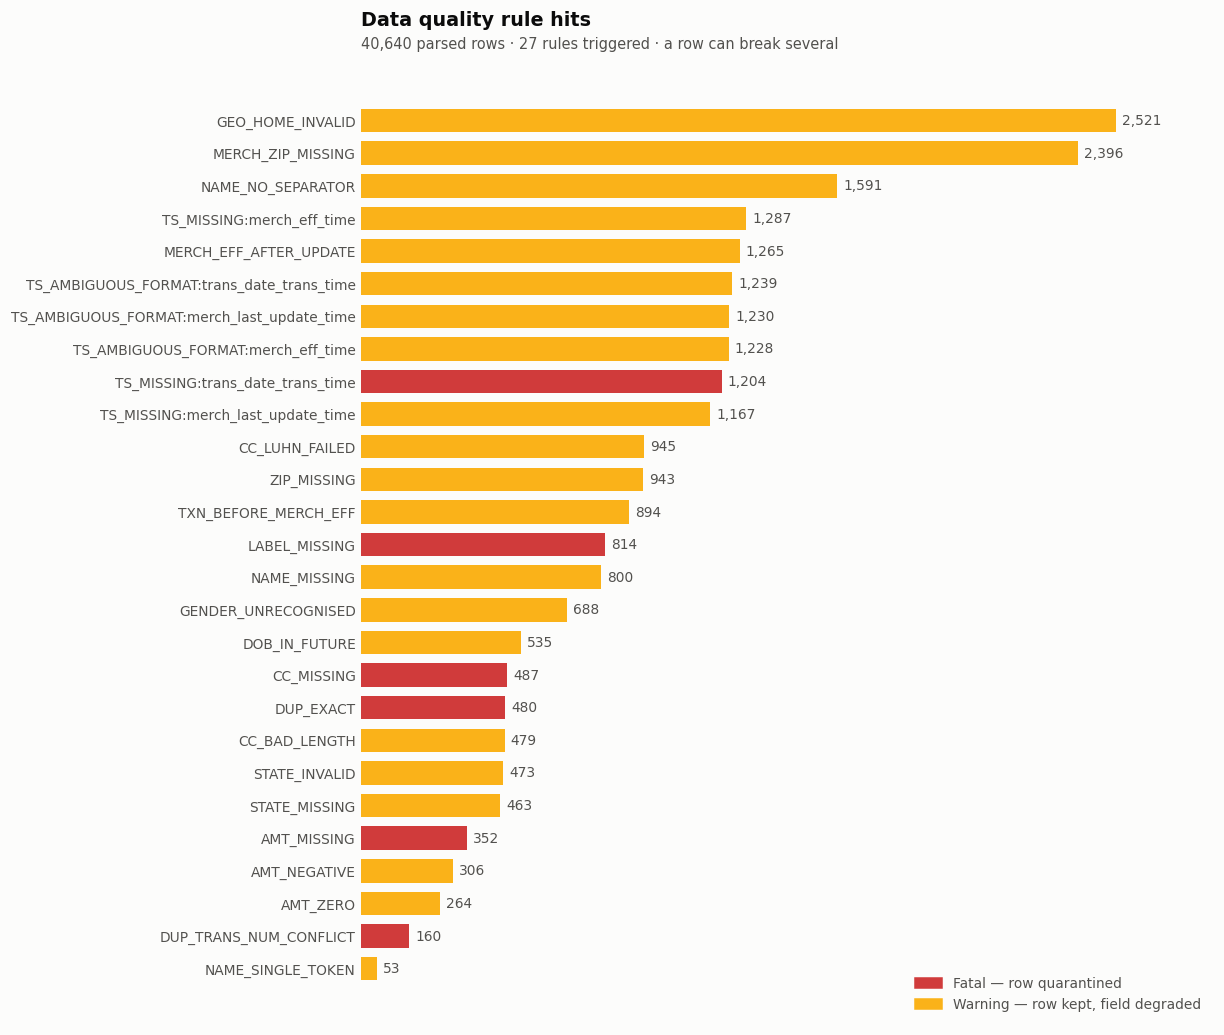

In [22]:
fig, ax = plt.subplots(figsize=(10, 0.36 * len(flag_counts) + 1.6))

order = flag_counts.sort_values("count")
colors = [vz.STATUS["critical"] if s == "fatal" else vz.STATUS["warning"]
          for s in order["severity"]]

bars = ax.barh(order["rule"], order["count"], color=colors, height=0.72)
vz.label_bars(ax, bars, fmt="{:,.0f}", horizontal=True)

ax.set_title("Data quality rule hits")
vz.subtitle(ax, f"{n_in:,} parsed rows · {len(flag_counts)} rules triggered · a row can break several")
ax.set_xlabel("")
ax.set_xticks([])
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.margins(x=0.13)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=vz.STATUS["critical"]),
    plt.Rectangle((0, 0), 1, 1, color=vz.STATUS["warning"]),
]
ax.legend(handles, ["Fatal — row quarantined", "Warning — row kept, field degraded"],
          loc="lower right", ncol=1)

vz.save(fig, "01_dq_scorecard")
plt.show()


**Reading it.** The fatal population is dominated by duplicates and by the timestamp column — which
is the expected shape for a feed assembled from re-runs with inconsistent time encoding. The warning
population is dominated by name-format drift and by missing merchant ZIPs; neither prevents analysis,
which is exactly why they are warnings.

The practical consequence: **roughly the whole feed survives**, and the part that does not is
accounted for line by line rather than vanishing between two `.filter()` calls.


In [23]:
# Quarantine is a deliverable, not a side effect. Write it with the reasons attached.
(
    reject_df
    .select("trans_num", "`Unnamed: 0`", "trans_date_trans_time_utc8", "amt", "dq_flags")
    .limit(10).toPandas()
)


,trans_num,Unnamed: 0,trans_date_trans_time_utc8,amt,dq_flags
0,003b5a3f198d36b43aabc637e97a2028,8449,2020-09-13 18:56:39.000000 +0800,24.94,"[TS_MISSING:merch_last_update_time, LABEL_MISS..."
1,0173021b9d46abe596dde65153863213,20344,2020-07-10 04:15:28.000000 +0800,30.03,[DUP_EXACT]
2,01e62daa3ddb2f419db42fa73d0e125d,5580,2019-05-30 23:27:06.000000 +0800,63.36,"[LABEL_MISSING, GEO_HOME_INVALID]"
3,0202ae1423447b56ed7d7b2f6c5b09f9,22836,2019-03-02 18:39:49.000000 +0800,28.49,[DUP_EXACT]
4,02203adb5dc1156a0c6ee132ae8bda63,3261,None,17.76,[TS_MISSING:trans_date_trans_time]
5,02397b8379883ccd3bccb67b1dcbf987,6758,2020-04-06 16:36:41.000000 +0800,70.03,[LABEL_MISSING]
6,02b4225a935c7278276a448aae5647ee,17835,2019-01-28 14:03:56.000000 +0800,118.49,[DUP_TRANS_NUM_CONFLICT]
7,050f2bdff92d899ebaac8af3fff95682,7802,2019-11-30 12:02:58.000000 +0800,18.17,[DUP_TRANS_NUM_CONFLICT]
8,068ca65a3c35bda75ed12e6e78910a97,21188,None,7.78,[TS_MISSING:trans_date_trans_time]
9,06dda71d0a74b0a5b4f563b04482e5a2,26092,2019-01-30 00:02:26.000000 +0800,34.98,[CC_MISSING]


---
## 5. PII handling

### 5.1 What is actually personal here

The columns split into three groups, and the split is what drives the treatment. Lumping them all
together as "PII" and hashing everything is the common mistake — it destroys analytical value on
the quasi-identifiers while leaving the direct identifiers only weakly protected.

| Group | Columns | Risk |
|---|---|---|
| **Direct identifiers** | `cc_num`, `first`, `last`, `street`, `trans_num` | Identify a person on their own. |
| **Quasi-identifiers** | `dob`, `zip`, `gender`, `job`, `lat`/`long`, `city`, `city_pop` | Identify nobody alone; identify almost anybody in combination. The classic result is that **ZIP + date of birth + gender is unique for a large majority of the US population** — so hashing the name and keeping those three achieves nothing. |
| **Non-personal** | `merchant`, `category`, `amt`, `is_fraud`, `cc_bic`, merchant geo | No treatment needed. `cc_bic` identifies the *issuing bank*, not the cardholder. |

### 5.2 The schema is a contract

The brief specifies 26 output columns. Protecting the data is therefore **not allowed to delete any
of them**, and two shortcuts that would are ruled out here:

- **Dropping a column** because it is sensitive. `street`, `first`, `last`, `cc_num` and `trans_num`
  are all in the required list; a table that omits them does not satisfy the spec, whatever its
  privacy properties.
- **Concatenating several identifiers into one hash** and keeping only that. It is one line of code
  and it collapses five distinct columns into a single opaque string — a loss of schema, not a
  privacy control. The consumer can no longer tell a missing surname from a missing card number,
  and nothing can be masked at a different strength later.

So every treatment below is applied **in place, column by column**: the column keeps its name, its
position and its meaning, and only the *precision of the value* changes. Derived keys —
`card_token`, `customer_token`, `cc_bin6`, `cc_last4`, `zip3`, `age_band` — are added **alongside**
the originals, never in place of them. `customer_token` is the one place a concatenation appears,
and it is a **derivation**: it builds a stable cardholder key from name + date of birth, while those
source columns stay in the table in their own right.

§5.5 ends with an explicit assertion that all 26 columns survived, printed next to the treatment
applied to each.

### 5.3 Why a keyed HMAC and not `sha2()`

The obvious move is `sha2(cc_num, 256)`. It does not work.

A card number is 16 digits with a fixed 6-digit BIN and a Luhn-constrained last digit, so the real
search space is about **10⁹ candidates per BIN**. An attacker holding the hashes and a commodity GPU
enumerates that in seconds and recovers every card number. The hash is not a one-way function when
the input domain is small — it is a lookup table.

Adding a *published* salt does not help either, since the salt is in the same file as the hashes.

What does work is a **keyed** HMAC-SHA256 with a secret that is never stored alongside the data. The
attacker now has to guess a 256-bit key rather than a 10-digit number. Concretely:

- the key comes from the `PII_HMAC_KEY` environment variable, never from the notebook or the repo;
- key rotation is a deliberate operation — rotating changes every token, which breaks joins to
  previously published extracts, so it needs a versioned token column in production;
- the token is deterministic, which is the whole point: the same card yields the same token across
  runs and across tables, so cardholder-level analysis still works without any card number present.

The same reasoning applies to `trans_num`: it is a pseudonymous identifier, low-entropy, and is
tokenised the same way — **in its own column**, so the required `trans_num` field is still there and
still joins to the quarantine table.

In [24]:
PII_HMAC_KEY = os.environ.get("PII_HMAC_KEY", "local-dev-key-not-for-production")
if PII_HMAC_KEY == "local-dev-key-not-for-production":
    print("WARNING: using the built-in development key. Set PII_HMAC_KEY for anything real.")


@pandas_udf(T.StringType())
def hmac_token(values: pd.Series) -> pd.Series:
    key = PII_HMAC_KEY.encode()          # captured once per executor, not per row
    def tok(v):
        if v is None:
            return None
        return hmac_lib.new(key, str(v).encode(), hashlib.sha256).hexdigest()[:32]
    return values.map(tok)


print("HMAC-SHA256 tokeniser ready (truncated to 128 bits — still far beyond brute force)")


HMAC-SHA256 tokeniser ready (truncated to 128 bits — still far beyond brute force)


### 5.4 Three layers, three audiences

Rather than one "cleaned" table, the pipeline emits three, each readable by a wider group than the
last. This is the part that makes the policy enforceable: access control has something to attach to.
**All three carry the full 26-column schema** — what changes between them is the precision of the
values, not the shape of the table.

| Layer | Contents | Who reads it |
|---|---|---|
| **Bronze — raw** | Exactly what arrived, untouched. | Nobody routinely. Retained for replay and audit, on restricted storage with a retention clock. |
| **Silver — curated** | Direct identifiers masked or tokenised in place. Quasi-identifiers still exact. | Engineers and fraud investigators who need to reach a specific cardholder through a case-management system. |
| **Gold — analytics** | Silver, plus quasi-identifiers generalised in place. | Analysts, dashboards, notebooks like the rest of this one. |

Column by column:

| Required column | Silver | Gold | Signal retained |
|---|---|---|---|
| `cc_num` | `374512******2099` | unchanged from silver | Issuer (BIN) and the last four, which is the form every statement and support call uses. |
| `first`, `last` | `J*****`, `R****` | unchanged from silver | Length and initial only — enough to eyeball a masked row, not enough to name anyone. Grouping moves to `customer_token`. |
| `street` | `[REDACTED]` | unchanged from silver | Nothing. A house number plus street is a direct identifier with no analytical use; the column survives, the value does not. |
| `trans_num` | HMAC token | unchanged from silver | Row identity and joins, without exposing the original reference. |
| `dob` | exact | truncated to **year of birth** | Age effects, via the `age_band` column derived beside it. |
| `zip` | exact | `468**` — ZIP3, suppressed to `000**` under 20,000 population | Regional geography. Mirrors the HIPAA Safe Harbor rule. |
| `lat`, `long` | exact | rounded to 1 dp (≈ 11 km) | Distance-to-merchant, which is the actual feature of interest, survives 11 km rounding intact. |
| `gender`, `job`, `city`, `city_pop`, `state` | exact | exact | Kept whole. Individually weak identifiers at this granularity; it is the *combination* with `zip` and `dob` that is dangerous, and that combination is what the gold layer breaks. |
| everything else | exact | exact | Non-personal. |

**What this does not do.** Tokenisation and generalisation reduce re-identification risk; they do
not eliminate it. A cardholder with a distinctive transaction pattern remains findable by anyone
holding an auxiliary dataset. Genuine guarantees need differential privacy or k-anonymity enforced
with suppression, and both cost accuracy. The right call for a fraud-analytics table is this
layering plus access control, with the residual risk written down rather than assumed away.

In [25]:
# ---- SILVER: protect the direct identifiers, in place ------------------
# Order matters and is the whole trick: the derived keys are added FIRST, so
# they are computed from the real values, and the masks are applied AFTER, so
# they overwrite the same column names. Nothing is dropped — silver has every
# column clean_df had, plus four derived ones.

# Format-preserving mask. The BIN identifies the issuer, not the person, and the
# last four is the form cardholders and support staff actually recognise; the
# ten digits in between are what make the number usable, so they are the ten
# that go. The short branch covers CC_BAD_LENGTH rows, which are warnings rather
# than fatal and so are still here.
cc_masked = F.expr("""
    CASE WHEN cc_num IS NULL THEN NULL
         WHEN length(cc_num) >= 11
             THEN concat(substring(cc_num, 1, 6),
                         repeat('*', length(cc_num) - 10),
                         substring(cc_num, -4, 4))
         ELSE repeat('*', length(cc_num))
    END
""")

def mask_name(colname):
    # "Sanchez" -> "S******". Keeping the initial and the length makes a masked
    # row readable for QA without making it identifying.
    return F.expr(
        f"CASE WHEN `{colname}` IS NULL THEN NULL "
        f"ELSE concat(substring(`{colname}`, 1, 1), "
        f"            repeat('*', greatest(length(`{colname}`) - 1, 0))) END"
    )

# The stable cardholder key. This concatenation is a *derivation* — first, last
# and dob all remain as columns in their own right; the token exists so that
# cardholder-level grouping survives the masking.
identity_key = F.concat_ws(
    "|",
    F.coalesce(F.col("first"), F.lit("")),
    F.coalesce(F.col("last"), F.lit("")),
    F.coalesce(F.date_format("dob", "yyyy-MM-dd"), F.lit("")),
)

silver_df = (
    clean_df
    # -- derived keys, from the unmasked values --
    .withColumn("card_token", hmac_token(F.col("cc_num")))
    .withColumn("cc_bin6", F.substring(F.col("cc_num"), 1, 6))
    .withColumn("cc_last4", F.substring(F.col("cc_num"), -4, 4))
    .withColumn("customer_token", hmac_token(identity_key))
    # -- masks, overwriting the same columns --
    .withColumn("cc_num", cc_masked)
    .withColumn("trans_num", hmac_token(F.col("trans_num")))
    .withColumn("first", mask_name("first"))
    .withColumn("last", mask_name("last"))
    .withColumn("street", F.when(F.col("street").isNotNull(), F.lit("[REDACTED]")))
)

lost = set(clean_df.columns) - set(silver_df.columns)
print(f"silver: {len(silver_df.columns)} columns, {len(lost)} dropped ({lost or 'none'})")
print("added :", sorted(set(silver_df.columns) - set(clean_df.columns)))

silver_df.select("cc_num", "cc_bin6", "cc_last4", "card_token",
                 "first", "last", "street", "trans_num", "customer_token").limit(5).toPandas()

silver: 40 columns, 0 dropped (none)
added : ['card_token', 'cc_bin6', 'cc_last4', 'customer_token']


,cc_num,cc_bin6,cc_last4,card_token,first,last,street,trans_num,customer_token
0,374512******2099,374512,2099,bb7a0a9c0eed4bf86d5f74988b897da8,J*****,R****,[REDACTED],bc2b72f4591725865ad8e38e19d0634e,793ef219e1cde8b1571237412cd1ce50
1,453201******0159,453201,0159,d2fdda2565d6953bfbd5be00ca773844,L****,K*******,[REDACTED],2b4beb103ded0034ecaefbaf4749d916,ad5e2625fe663da755eda6041f31294c
2,541122******0667,541122,0667,5cab0d4d907eb419abf87fdae027e987,P****,F******,[REDACTED],b264ac393db8875be0c0439981aa6d72,e3e8c7e5987e162acd26bf275b2db7b2
3,453201******8806,453201,8806,d75f06b403d5ae570cdd22d067a6bf95,K****,N****,[REDACTED],fce89de3cfad50bfc0c2158e1f2462ef,537753b3903bc936addbcfa7c7f5bd0d
4,270318******6944,270318,6944,6e0db8602ff491e10db92378d1d526a6,A****,B****,[REDACTED],201e021b28d519504965a368814a7777,01ffd043cf06e7eb453a91356bb6c6f6


In [26]:
# ---- GOLD: generalise the quasi-identifiers, also in place -------------
# HIPAA Safe Harbor suppresses ZIP3 areas with fewer than 20,000 people. Using
# the feed's own population figure as the proxy.
zip3 = F.when(F.col("city_pop") >= 20000, F.substring(F.col("zip"), 1, 3)).otherwise(F.lit("000"))

age_band = (
    F.when(F.col("age") < 25, "18-24")
     .when(F.col("age") < 35, "25-34")
     .when(F.col("age") < 45, "35-44")
     .when(F.col("age") < 55, "45-54")
     .when(F.col("age") < 65, "55-64")
     .when(F.col("age") < 75, "65-74")
     .when(F.col("age") >= 75, "75+")
)

gold_df = (
    silver_df
    # -- the analysis-friendly generalisations, added beside the originals --
    .withColumn("zip3", zip3)
    .withColumn("age_band", age_band)
    # -- the originals, coarsened in place rather than removed --
    # zip keeps five characters so it still reads as a ZIP: "46805" -> "468**".
    .withColumn("zip", F.when(F.col("zip").isNotNull(), F.concat(F.col("zip3"), F.lit("**"))))
    # dob stays a date, at year-of-birth precision: 1985-03-14 -> 1985-01-01.
    .withColumn("dob", F.trunc(F.col("dob"), "year"))
    # ~11 km at 1 dp — below the resolution at which distance-to-merchant matters.
    .withColumn("lat", F.round(F.col("lat"), 1))
    .withColumn("long", F.round(F.col("long"), 1))
    .cache()
)

lost = set(silver_df.columns) - set(gold_df.columns)
print(f"gold: {gold_df.count():,} rows x {len(gold_df.columns)} columns, {len(lost)} dropped ({lost or 'none'})")

gold_df.select("customer_token", "dob", "age_band", "zip", "zip3", "gender",
               "lat", "long", "amt", "category", "is_fraud").limit(5).toPandas()

gold: 37,246 rows x 42 columns, 0 dropped (none)


,customer_token,dob,age_band,zip,zip3,gender,lat,long,amt,category,is_fraud
0,793ef219e1cde8b1571237412cd1ce50,1979-01-01,35-44,468**,468,F,41.1,-85.2,17.83,health_fitness,0
1,ad5e2625fe663da755eda6041f31294c,1983-01-01,35-44,370**,370,M,36.5,-87.4,20.11,misc_net,0
2,e3e8c7e5987e162acd26bf275b2db7b2,1949-01-01,65-74,000**,000,F,38.4,-79.5,36.01,misc_net,0
3,537753b3903bc936addbcfa7c7f5bd0d,1999-01-01,18-24,852**,852,M,33.4,-111.9,22.11,entertainment,0
4,01ffd043cf06e7eb453a91356bb6c6f6,1983-01-01,35-44,770**,770,F,NaN,-95.5,61.45,kids_pets,0


### 5.5 The schema contract, verified

The claim made in §5.2 is that PII handling changed values and added columns but removed none. That
is checkable, so it is checked rather than asserted: the cell below fails loudly if any of the 26
required columns is missing from the analytics layer, and prints the treatment applied to each next
to a real value from the table.

In [27]:
# Treatment applied to each required column. Anything not listed is carried
# through unchanged because it is not personal data.
PII_TREATMENT = {
    "cc_num":    "masked in place — BIN + last 4",
    "first":     "masked in place — initial + length",
    "last":      "masked in place — initial + length",
    "street":    "redacted in place",
    "trans_num": "HMAC-SHA256 token in place",
    "dob":       "generalised in place — year of birth",
    "zip":       "generalised in place — ZIP3 + suppression",
    "lat":       "generalised in place — 1 dp (~11 km)",
    "long":      "generalised in place — 1 dp (~11 km)",
}

missing = [c for c in TARGET_COLUMNS if c not in gold_df.columns]
assert not missing, f"required columns lost to PII handling: {missing}"

_sample = (
    gold_df
    .select([F.col(f"`{c}`").cast("string").alias(c) for c in TARGET_COLUMNS])
    .limit(1).toPandas().iloc[0]
)

contract = pd.DataFrame({
    "required column": TARGET_COLUMNS,
    "treatment": [PII_TREATMENT.get(c, "carried through unchanged") for c in TARGET_COLUMNS],
    "example value": [_sample[c] for c in TARGET_COLUMNS],
})

print(f"all {len(TARGET_COLUMNS)} required columns present\n"
      f"{len(PII_TREATMENT)} treated in place, "
      f"{len(TARGET_COLUMNS) - len(PII_TREATMENT)} unchanged\n"
      f"derived columns added alongside: "
      f"{sorted(set(gold_df.columns) - set(clean_df.columns))}")
contract

all 26 required columns present
9 treated in place, 17 unchanged
derived columns added alongside: ['age_band', 'card_token', 'cc_bin6', 'cc_last4', 'customer_token', 'zip3']


,required column,treatment,example value
0,Unnamed: 0,carried through unchanged,1140
1,trans_date_trans_time,carried through unchanged,2020-09-01 02:37:00
2,cc_num,masked in place — BIN + last 4,374512******2099
3,merchant,carried through unchanged,Reichel LLC
4,category,carried through unchanged,health_fitness
5,amt,carried through unchanged,17.83
6,first,masked in place — initial + length,J*****
7,last,masked in place — initial + length,R****
8,gender,carried through unchanged,F
9,street,redacted in place,[REDACTED]


In [28]:
# Evidence that the generalisation did something. The ZIP+DOB+gender triple is
# the textbook re-identification vector; measure how unique it was, and is.
def uniqueness(frame, cols, label):
    grp = frame.groupBy(*cols).count()
    total = frame.count()
    unique = grp.filter(F.col("count") == 1).count()
    small = grp.filter(F.col("count") < 5).count()
    print(f"{label:<34} groups={grp.count():>7,}  unique(k=1)={unique:>7,}  k<5 groups={small:>7,}")

uniqueness(clean_df, ["zip", "dob", "gender"], "exact zip + dob + gender")
uniqueness(gold_df,  ["zip3", "age_band", "gender"], "zip3 + age_band + gender")


exact zip + dob + gender           groups=  2,643  unique(k=1)=    994  k<5 groups=  1,665
zip3 + age_band + gender           groups=    312  unique(k=1)=     12  k<5 groups=     47


The `k=1` count is the number of combinations matching exactly one person — each of those is a
successful re-identification for anyone holding a matching external record. Generalisation collapses
them, and that is the measurable output of the PII work rather than an assertion that it was done.


---
## 6. Feature engineering

Four derived features, each intended to answer a question the raw columns cannot.

**`distance_km`** — great-circle distance between the cardholder's home and the merchant, via the
haversine formula. Written as Spark SQL rather than a UDF so it stays inside the JVM and the Catalyst
optimiser can see it. This is the single most useful engineered feature for card-present fraud:
a card physically present 900 km from its home address is a strong signal.

**`local_hour` / `local_dow`** — extracted **after** converting to UTC+8, because fraud is a
behavioural phenomenon and behaviour follows the local clock, not UTC. Bucketing by UTC hour on a
+8 population smears the overnight peak across two adjacent buckets and weakens the very signal the
chart is looking for.

**`merchant_tenure_days`** — how long the merchant had been registered when the transaction
happened, from `merch_eff_time`. This is the column the brief adds beyond the standard dataset, and
it turns out to carry signal.

**`amt_zscore_in_category`** — the amount relative to its own category's distribution, via a window.
A £200 grocery run and a £200 flight are not comparable in absolute terms; both are comparable as
deviations from their category norm.


In [29]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Pure Spark expressions — no Python round trip.
    r = F.lit(6371.0)
    p1, p2 = F.radians(lat1), F.radians(lat2)
    dphi = p2 - p1
    dlmb = F.radians(lon2 - lon1)
    a = F.pow(F.sin(dphi / 2), 2) + F.cos(p1) * F.cos(p2) * F.pow(F.sin(dlmb / 2), 2)
    return r * 2 * F.asin(F.sqrt(a))


w_cat = Window.partitionBy("category")

feat_df = (
    gold_df
    .withColumn("distance_km",
                F.round(haversine_km(F.col("lat"), F.col("long"),
                                     F.col("merch_lat"), F.col("merch_long")), 2))
    .withColumn("local_ts", F.from_utc_timestamp("trans_date_trans_time", DISPLAY_TZ))
    .withColumn("local_hour", F.hour("local_ts"))
    .withColumn("local_dow", F.date_format("local_ts", "E"))
    .withColumn("local_date", F.to_date("local_ts"))
    .withColumn("merchant_tenure_days",
                F.datediff(F.col("trans_date_trans_time"), F.col("merch_eff_time")))
    .withColumn("amt_zscore_in_category",
                F.round((F.col("amt") - F.avg("amt").over(w_cat))
                        / F.stddev("amt").over(w_cat), 3))
    .cache()
)

print(f"{feat_df.count():,} rows ready for analysis")
feat_df.select("local_ts", "local_hour", "local_dow", "distance_km",
               "merchant_tenure_days", "amt", "amt_zscore_in_category", "is_fraud").limit(6).toPandas()

37,246 rows ready for analysis


,local_ts,local_hour,local_dow,distance_km,merchant_tenure_days,amt,amt_zscore_in_category,is_fraud
0,2019-11-16 07:05:33,7,Sat,434.53,2594.0,329.21,4.159,0
1,2020-02-04 19:30:58,19,Tue,76.24,2017.0,131.64,1.050,0
2,2020-01-28 00:14:47,0,Tue,1239.73,NaN,-155.08,-3.462,0
3,2020-11-01 09:29:31,9,Sun,2320.89,2037.0,77.75,0.202,0
4,2020-04-03 09:55:11,9,Fri,2232.16,816.0,127.24,0.981,0
5,2020-01-26 06:59:28,6,Sun,2207.41,NaN,91.88,0.424,0


In [30]:
# Headline numbers, computed once and reused by the charts below.
kpi = feat_df.agg(
    F.count("*").alias("txns"),
    F.countDistinct("customer_token").alias("customers"),
    F.sum("amt").alias("total_amt"),
    F.sum("is_fraud").alias("fraud_txns"),
    F.sum(F.when(F.col("is_fraud") == 1, F.col("amt")).otherwise(0.0)).alias("fraud_amt"),
    F.min("local_date").alias("from_date"),
    F.max("local_date").alias("to_date"),
).toPandas().iloc[0]

OVERALL_FRAUD_RATE = kpi["fraud_txns"] / kpi["txns"]
print(kpi.to_string())
print(f"\noverall fraud rate: {OVERALL_FRAUD_RATE:.3%}")


txns               37246
customers           2060
total_amt     2070887.83
fraud_txns           760
fraud_amt      171015.55
from_date     2019-01-01
to_date       2021-01-01

overall fraud rate: 2.040%


---
## 7. Visualisation and analysis

Each figure below states what question it answers and why that chart form was chosen, because the
form is a decision and not a default. A few conventions hold throughout:

- **One axis per chart.** Two measures on two scales would be two charts, never two y-axes.
- **Colour is assigned by job.** Magnitude gets a single-hue sequential ramp; identity gets
  categorical slots in fixed order; the fraud *state* gets a reserved status colour. Colour never
  carries meaning alone — every chart with more than one series has both a legend and labels.
- **Every figure is accompanied by its table.** These are static images with no hover layer, so the
  underlying numbers are printed rather than hidden behind a tooltip.
- **Rates, not counts, wherever the base differs.** Fraud *counts* by category mostly measure how
  popular the category is. Fraud *rate* measures risk.


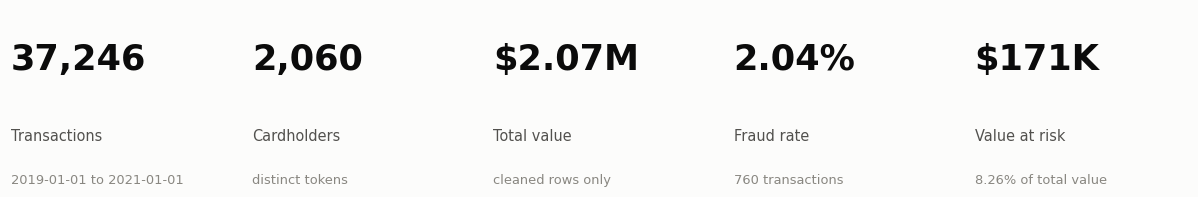

In [31]:
# Shared helper: fraud rate plus the base it is computed from. The base matters —
# a 40% fraud rate over five transactions is noise, and the table has to show it.
def fraud_rate_by(frame, col, min_base=50):
    pdf = (
        frame.groupBy(col)
        .agg(F.count("*").alias("txns"),
             F.sum("is_fraud").alias("fraud_txns"),
             F.sum(F.when(F.col("is_fraud") == 1, F.col("amt")).otherwise(0.0)).alias("fraud_amt"),
             F.avg("amt").alias("avg_amt"))
        .toPandas()
    )
    pdf["fraud_rate"] = pdf["fraud_txns"] / pdf["txns"]
    pdf["reliable"] = pdf["txns"] >= min_base
    return pdf


fig = vz.stat_tiles([
    ("Transactions",      f"{int(kpi['txns']):,}",        f"{kpi['from_date']} to {kpi['to_date']}"),
    ("Cardholders",       f"{int(kpi['customers']):,}",   "distinct tokens"),
    ("Total value",       f"${kpi['total_amt']/1e6:,.2f}M", "cleaned rows only"),
    ("Fraud rate",        f"{OVERALL_FRAUD_RATE:.2%}",    f"{int(kpi['fraud_txns']):,} transactions"),
    ("Value at risk",     f"${kpi['fraud_amt']/1e3:,.0f}K", f"{kpi['fraud_amt']/kpi['total_amt']:.2%} of total value"),
])
vz.save(fig, "02_kpi_tiles")
plt.show()


**Why tiles and not a chart.** Five single magnitudes with no comparison to draw between them. A bar
chart of unrelated quantities on one scale would imply a comparison that does not exist; the number
itself is the whole message.

Note the gap between the last two tiles: fraud is **2% of transactions but a visibly larger share of
value**. That gap is the reason the rest of this section keeps separating rate from value.


### 7.1 When does fraud happen?

**Question:** does fraud follow the local clock?
**Form:** a vertical bar chart over 24 ordered, evenly-spaced buckets. Hour-of-day is cyclical and
categorical-but-ordered, which is bar territory; a line would imply continuous interpolation between
02:00 and 03:00 that the aggregation does not support.
**Colour:** one measure, one hue. The overall rate is drawn as a labelled reference line rather than
as a second series, which keeps the chart on one axis and makes "above or below average" readable
without a legend.

This is the chart that justifies doing the timezone conversion properly. The same aggregation over
raw UTC would spread the overnight peak across the wrong buckets.


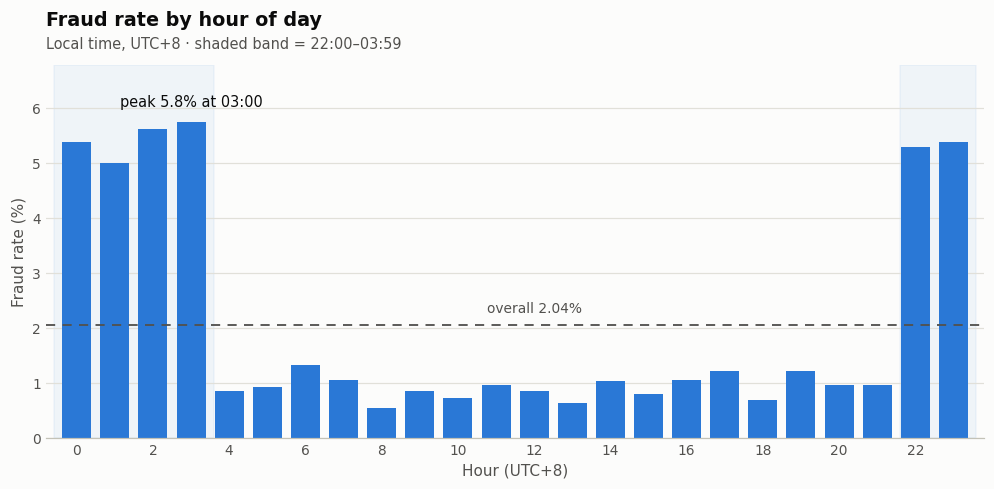

22:00–03:59  5.40% over 9,312 txns
04:00–21:59  0.92% over 27,934 txns
lift         5.9x

 local_hour  txns  fraud_txns  fraud_rate
          0  1504          81    0.053856
          1  1598          80    0.050063
          2  1547          87    0.056238
          3  1530          88    0.057516
          4  1522          13    0.008541
          5  1617          15    0.009276
          6  1588          21    0.013224
          7  1533          16    0.010437
          8  1510           8    0.005298
          9  1521          13    0.008547
         10  1541          11    0.007138
         11  1559          15    0.009622
         12  1524          13    0.008530
         13  1572          10    0.006361
         14  1563          16    0.010237
         15  1633          13    0.007961
         16  1524          16    0.010499
         17  1487          18    0.012105
         18  1613          11    0.006820
         19  1480          18    0.012162
         20  1566          1

In [32]:
by_hour = fraud_rate_by(feat_df, "local_hour").sort_values("local_hour")

fig, ax = plt.subplots(figsize=(11, 4.4))
bars = ax.bar(by_hour["local_hour"], by_hour["fraud_rate"] * 100,
              color=vz.CATEGORICAL[0], width=0.76)

# The overnight window, called out as an annotated band rather than a second colour.
ax.axvspan(21.6, 23.6, color=vz.CATEGORICAL[0], alpha=0.06, zorder=0)
ax.axvspan(-0.6, 3.6, color=vz.CATEGORICAL[0], alpha=0.06, zorder=0)

ax.axhline(OVERALL_FRAUD_RATE * 100, color=vz.INK["secondary"], linewidth=1.2, linestyle=(0, (5, 4)))
# Parked mid-afternoon, where the bars are short — at the right-hand edge it
# would sit on top of the 23:00 bar.
ax.annotate(f"overall {OVERALL_FRAUD_RATE:.2%}",
            xy=(12, OVERALL_FRAUD_RATE * 100), xytext=(0, 7), textcoords="offset points",
            ha="center", va="bottom", fontsize=9, color=vz.INK["secondary"])

peak = by_hour.loc[by_hour["fraud_rate"].idxmax()]
ax.annotate(f"peak {peak['fraud_rate']:.1%} at {int(peak['local_hour']):02d}:00",
            xy=(peak["local_hour"], peak["fraud_rate"] * 100),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=9.5, color=vz.INK["primary"])

ax.set_title("Fraud rate by hour of day")
vz.subtitle(ax, "Local time, UTC+8 · shaded band = 22:00–03:59")
ax.set_xlabel("Hour (UTC+8)")
ax.set_ylabel("Fraud rate (%)")
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.8, 23.8)
vz.strip_x_grid(ax)
ax.margins(y=0.18)

vz.save(fig, "03_fraud_by_hour")
plt.show()

night = by_hour[by_hour["local_hour"].isin([22, 23, 0, 1, 2, 3])]
day = by_hour[~by_hour["local_hour"].isin([22, 23, 0, 1, 2, 3])]
print(f"22:00–03:59  {night['fraud_txns'].sum() / night['txns'].sum():.2%} over {night['txns'].sum():,} txns")
print(f"04:00–21:59  {day['fraud_txns'].sum() / day['txns'].sum():.2%} over {day['txns'].sum():,} txns")
print(f"lift         {(night['fraud_txns'].sum() / night['txns'].sum()) / (day['fraud_txns'].sum() / day['txns'].sum()):.1f}x")
print()
print(by_hour[["local_hour", "txns", "fraud_txns", "fraud_rate"]].to_string(index=False))


**Finding.** Fraud is concentrated overnight in local time, at several times the daytime rate, while
the *volume* of legitimate transactions in that window is at its lowest. That combination — high risk,
low volume — is the ideal place to put a stricter rule, because the false-positive cost is paid by
the fewest genuine customers. A blanket threshold applied across all 24 hours would be simultaneously
too loose at 02:00 and too tight at 14:00.


### 7.2 Which categories carry the risk?

**Question:** is risk concentrated in particular merchant categories, and is it the same set that
carries the money?
**Form:** horizontal bars, sorted by rate. Fourteen categories with long snake_case labels — rotating
those under a vertical axis would be unreadable, and sorting turns the chart into a ranking, which is
the actual question.
**Chrome:** the value labels replace the x-axis entirely. When every bar is labelled, an axis is
redundant chrome.


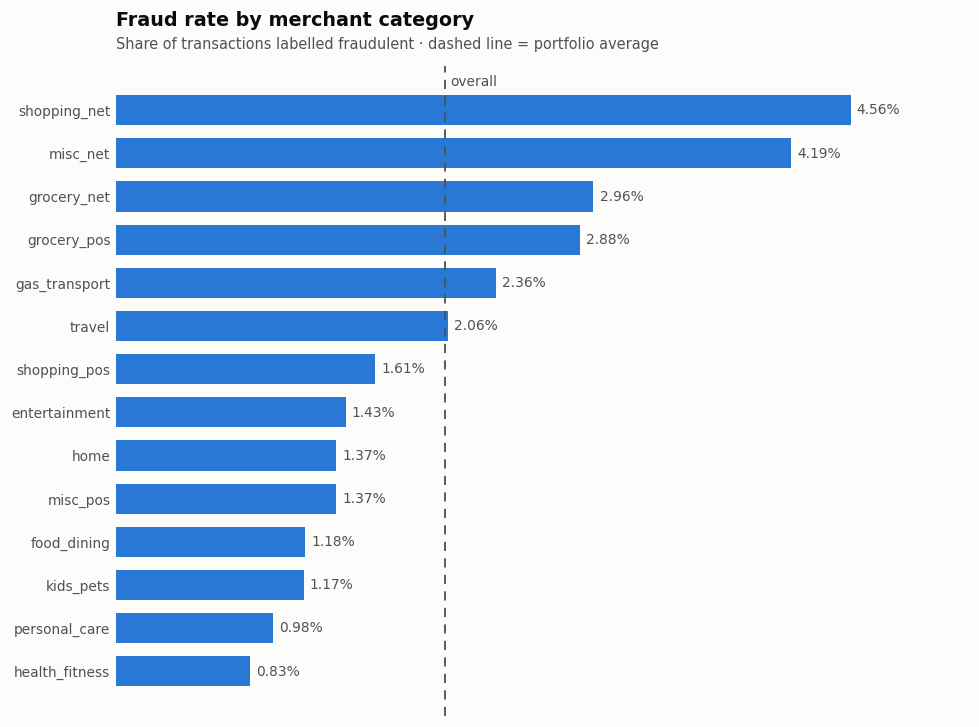

      category  txns  fraud_txns fraud_rate  share_of_fraud_value
  shopping_net  2719         124      4.56%                  22.8
      misc_net  2768         116      4.19%                  14.7
   grocery_net  1990          59      2.96%                   5.5
   grocery_pos  2710          78      2.88%                  10.2
 gas_transport  2540          60      2.36%                   5.0
        travel  2616          54      2.06%                  18.5
  shopping_pos  2298          37      1.61%                   3.2
 entertainment  3085          44      1.43%                   5.0
          home  2484          34      1.37%                   5.8
      misc_pos  2415          33      1.37%                   2.1
   food_dining  2972          35      1.18%                   1.8
     kids_pets  2828          33      1.17%                   2.3
 personal_care  3172          31      0.98%                   1.6
health_fitness  2649          22      0.83%                   1.6


In [33]:
by_cat = fraud_rate_by(feat_df, "category").sort_values("fraud_rate")

fig, ax = plt.subplots(figsize=(10, 0.42 * len(by_cat) + 1.8))
bars = ax.barh(by_cat["category"], by_cat["fraud_rate"] * 100,
               color=vz.CATEGORICAL[0], height=0.7)
vz.label_bars(ax, bars, fmt="{:.2f}%", horizontal=True)

ax.axvline(OVERALL_FRAUD_RATE * 100, color=vz.INK["secondary"], linewidth=1.2, linestyle=(0, (5, 4)))
ax.annotate("overall", xy=(OVERALL_FRAUD_RATE * 100, len(by_cat) - 0.35),
            xytext=(4, 0), textcoords="offset points",
            fontsize=9, color=vz.INK["secondary"], va="center")

ax.set_title("Fraud rate by merchant category")
vz.subtitle(ax, "Share of transactions labelled fraudulent · dashed line = portfolio average")
ax.set_xticks([])
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.margins(x=0.16)

vz.save(fig, "04_fraud_by_category")
plt.show()

tbl = by_cat.sort_values("fraud_rate", ascending=False).copy()
tbl["fraud_rate"] = (tbl["fraud_rate"] * 100).round(2).astype(str) + "%"
tbl["share_of_fraud_value"] = (100 * tbl["fraud_amt"] / tbl["fraud_amt"].sum()).round(1)
print(tbl[["category", "txns", "fraud_txns", "fraud_rate", "share_of_fraud_value"]].to_string(index=False))


**Finding, and the trap it avoids.** The riskiest categories by *rate* are the card-not-present ones
(`shopping_net`, `misc_net`) together with `grocery_pos`. But the final column is the interesting one:
the ranking by **share of fraud value** is not the same ranking. A category can have a modest fraud
rate and still dominate losses because its average ticket is large — `travel` behaves this way.

An operations team optimising the number of fraud cases and a finance team optimising loss in dollars
would reach different conclusions from the same feed. Showing rate and value share side by side is
what stops one of them being quietly wrong.


### 7.3 Do fraudulent amounts look different?

**Question:** can amount alone separate fraud from legitimate spend?
**Form:** two density curves on a log-scaled amount axis. A histogram of counts would be useless here
— fraud is 2% of rows, so its bars would be invisible next to the legitimate ones. Normalising each
series to its own density answers the shape question ("where does *this* population sit?") rather than
the volume question.
**Colour:** two series, so two categorical slots in fixed order, plus a legend *and* direct labels at
each peak. The log axis is necessary rather than decorative — amounts span four orders of magnitude,
and on a linear axis 97% of the data would occupy the leftmost centimetre.


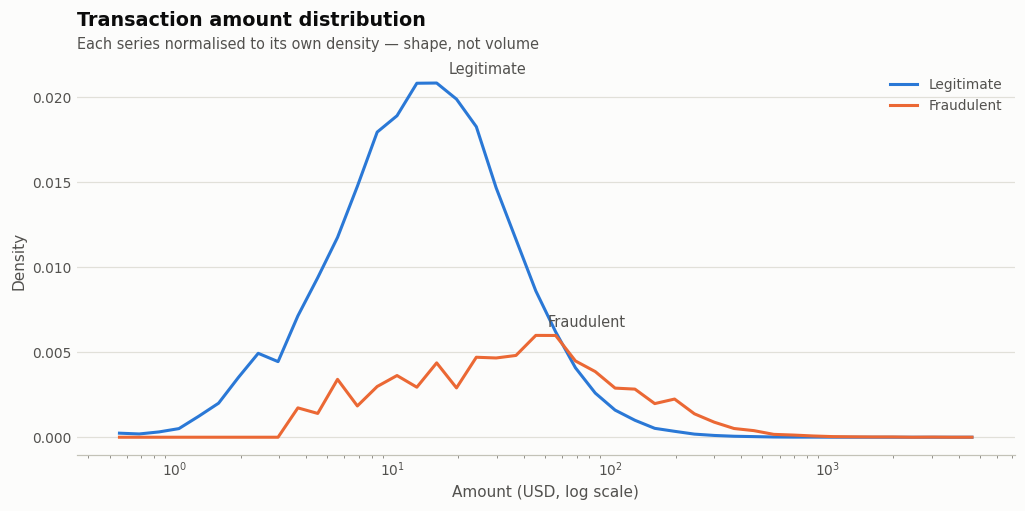

       Legitimate  Fraudulent
count    35961.00      751.00
mean        53.23      230.26
std         84.45      385.23
min          0.42        4.02
25%         17.33       57.51
50%         31.40      121.75
75%         58.35      245.28
95%        163.42      729.39
99%        375.11     1939.30
max       4167.30     5097.85


In [34]:
amts = (
    feat_df.filter((F.col("amt") > 0) & (F.col("amt").isNotNull()))
    .select("amt", "is_fraud").toPandas()
)

legit = amts.loc[amts["is_fraud"] == 0, "amt"]
fraud = amts.loc[amts["is_fraud"] == 1, "amt"]
bins = np.logspace(np.log10(0.5), np.log10(max(amts["amt"].max(), 10)), 45)

fig, ax = plt.subplots(figsize=(11, 4.6))
for series, label, color in [
    (legit, "Legitimate", vz.CATEGORICAL[0]),
    (fraud, "Fraudulent", vz.CATEGORICAL[1]),
]:
    counts, edges = np.histogram(series, bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])
    ax.plot(centres, counts, color=color, linewidth=2.0, label=label)
    # Direct label at the modal point, so identity does not rest on the legend alone.
    i = int(np.argmax(counts))
    ax.annotate(label, xy=(centres[i], counts[i]), xytext=(8, 6), textcoords="offset points",
                fontsize=9.5, color=vz.INK["secondary"])

ax.set_xscale("log")
ax.set_title("Transaction amount distribution")
vz.subtitle(ax, "Each series normalised to its own density — shape, not volume")
ax.set_xlabel("Amount (USD, log scale)")
ax.set_ylabel("Density")
ax.legend(loc="upper right")
vz.strip_x_grid(ax)

vz.save(fig, "05_amount_distribution")
plt.show()

print(
    pd.DataFrame({
        "Legitimate": legit.describe(percentiles=[.25, .5, .75, .95, .99]),
        "Fraudulent": fraud.describe(percentiles=[.25, .5, .75, .95, .99]),
    }).round(2).to_string()
)


**Finding.** The two distributions overlap heavily through the low and middle ranges but separate in
the upper tail — the fraud median sits well above the legitimate median, and the gap widens at the
95th and 99th percentiles.

The operational reading is the cautious one: **amount alone is a weak classifier**. The overlap
region contains the overwhelming majority of both populations, so any single amount threshold either
misses most fraud or flags an unacceptable number of genuine customers. Amount earns its place as a
*feature combined with others* — high amount **and** overnight **and** far from home — not as a rule
on its own. Charts like this are most useful for the threshold they rule out.


### 7.4 Hour × day-of-week

**Question:** is the overnight effect from §7.1 uniform across the week, or does it have structure?
**Form:** a heatmap. Two categorical dimensions crossed against one measure is exactly what the form
is for — 168 buckets would be unreadable as bars.
**Colour:** continuous magnitude, so a **single-hue sequential ramp**, light for low and dark for
high. Not a rainbow: a multi-hue scale invents category boundaries where the data has a smooth
gradient, and it is not monotonic in perceived lightness, so readers cannot rank two cells by eye.
A colourbar plus the printed matrix carries the values.


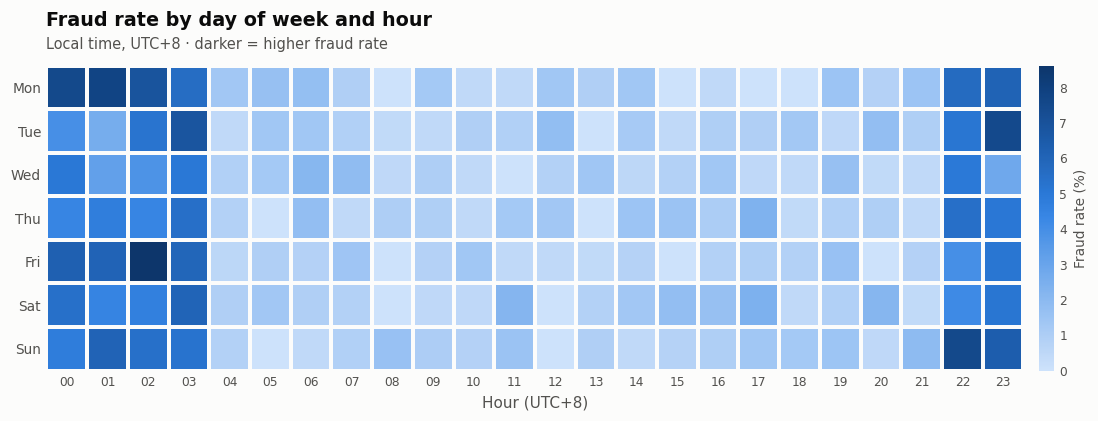

Fraud rate (%) — rows = day, columns = hour, UTC+8

local_hour   0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23
local_dow                                                                                                                         
Mon         7.5  7.8  6.9  5.6  1.3  1.7  1.7  0.9  0.0  1.3  0.5  0.4  1.4  0.9  1.4  0.0  0.4  0.0  0.0  1.5  0.8  1.5  5.7  6.1
Tue         4.0  2.6  5.2  6.8  0.5  1.4  1.4  0.9  0.4  0.4  0.9  0.9  1.8  0.0  1.2  0.5  1.0  0.9  1.3  0.5  1.8  0.9  5.2  7.5
Wed         5.0  3.2  3.8  5.1  0.9  1.2  2.1  1.9  0.5  1.0  0.5  0.0  0.8  1.4  0.5  0.9  1.4  0.5  0.5  1.7  0.4  0.5  5.0  2.8
Thu         4.4  4.7  4.4  5.5  0.9  0.0  1.8  0.5  1.0  1.0  0.4  1.3  1.3  0.0  1.5  1.5  1.1  2.4  0.4  0.9  1.0  0.5  5.5  5.1
Fri         6.2  6.1  8.6  5.9  0.6  0.9  0.8  1.4  0.0  0.8  1.4  0.4  0.5  0.4  0.8  0.0  0.8  0.9  0.9  1.6  0.0  0.8  4.0  5.1
Sat         5.4  4.5  4.6  6.0 

In [35]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

grid = (
    feat_df.groupBy("local_dow", "local_hour")
    .agg(F.count("*").alias("txns"), F.sum("is_fraud").alias("fraud"))
    .toPandas()
)
grid["rate"] = 100 * grid["fraud"] / grid["txns"]
matrix = (
    grid.pivot(index="local_dow", columns="local_hour", values="rate")
    .reindex(DOW).reindex(columns=range(24))
)

fig, ax = plt.subplots(figsize=(12, 3.6))
im = ax.pcolormesh(np.arange(25), np.arange(8), matrix.values,
                   cmap=vz.SEQ_CMAP, edgecolors=vz.INK["surface"], linewidth=1.4)

ax.set_title("Fraud rate by day of week and hour")
vz.subtitle(ax, "Local time, UTC+8 · darker = higher fraud rate")
ax.set_xticks(np.arange(24) + 0.5)
ax.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=8)
ax.set_yticks(np.arange(7) + 0.5)
ax.set_yticklabels(DOW)
ax.set_xlabel("Hour (UTC+8)")
ax.invert_yaxis()
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("Fraud rate (%)", color=vz.INK["secondary"], fontsize=9)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, color=vz.INK["muted"], labelcolor=vz.INK["secondary"])

vz.save(fig, "06_hour_dow_heatmap")
plt.show()

print("Fraud rate (%) — rows = day, columns = hour, UTC+8\n")
print(matrix.round(1).fillna(0).to_string())


**Finding.** The overnight band runs across every day of the week rather than clustering on weekends,
which says the effect is about **when monitoring and cardholder attention are thinnest**, not about
when people shop. A weekend-specific pattern would suggest something about consumer behaviour; a
uniform nightly band suggests something about the adversary.

The cells are small and some have thin bases, so the matrix is printed underneath — a cell built from
30 transactions and a cell built from 300 look identical in colour, and that is a real limitation of
the form rather than something to design away.


### 7.5 Three risk gradients, on one scale

**Question:** how do distance from home, merchant tenure, and cardholder age each move the fraud rate?
**Form:** small multiples. Three separate charts would invite the reader to compare shapes across
three different y-scales, which is the most common way a chart lies. One shared y-axis makes the
comparison honest: **a taller bar means more risk, in any panel**.
**Colour:** one measure throughout, so one hue throughout. Colour is doing no work here — position
is — and giving each panel its own colour would imply a distinction that does not exist.


distance quintile edges (km): [671, 1511, 2576, 3340]


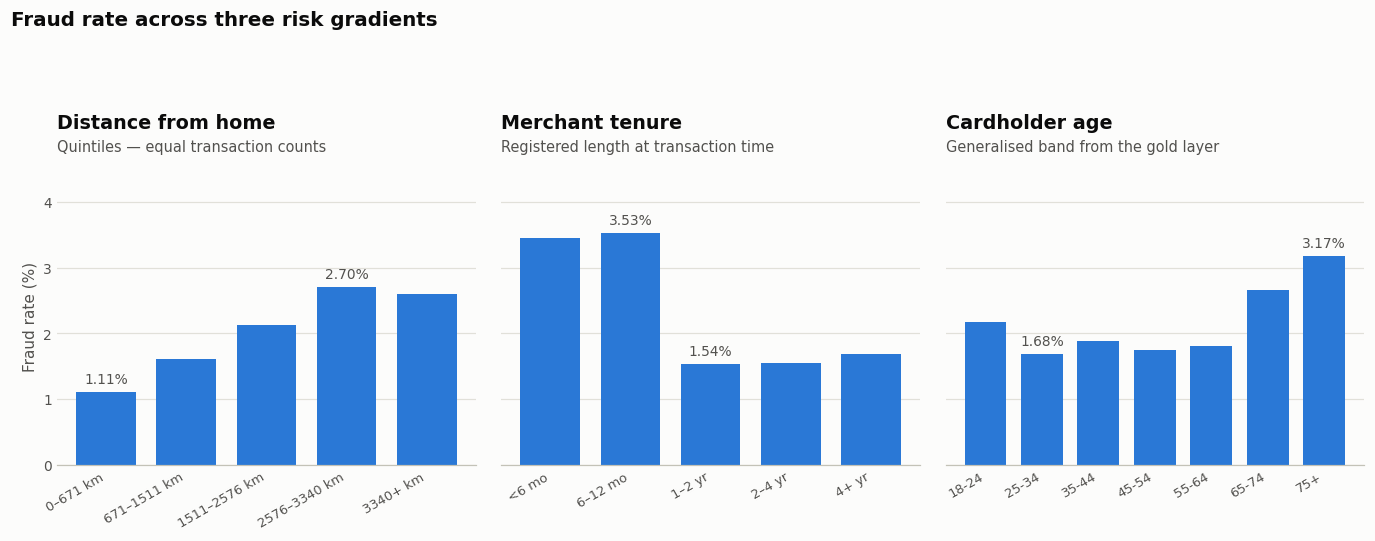


=== Distance from home ===
               txns  fraud_txns  fraud_rate
distance_band                              
0–671 km       6869          76      0.0111
671–1511 km    7007         113      0.0161
1511–2576 km   6899         147      0.0213
2576–3340 km   6922         187      0.0270
3340+ km       7270         189      0.0260

=== Merchant tenure ===
              txns  fraud_txns  fraud_rate
tenure_band                               
<6 mo         4875         168      0.0345
6–12 mo       2779          98      0.0353
1–2 yr        3908          60      0.0154
2–4 yr        7681         119      0.0155
4+ yr        15960         270      0.0169

=== Cardholder age ===
          txns  fraud_txns  fraud_rate
age_band                              
18-24     3089          67      0.0217
25-34     5701          96      0.0168
35-44     5780         109      0.0189
45-54     6746         118      0.0175
55-64     5887         106      0.0180
65-74     5770         153      0.0265
75

In [36]:
tenure_band = (
    F.when(F.col("merchant_tenure_days").isNull() | (F.col("merchant_tenure_days") < 0), None)
     .when(F.col("merchant_tenure_days") < 180, "<6 mo")
     .when(F.col("merchant_tenure_days") < 365, "6–12 mo")
     .when(F.col("merchant_tenure_days") < 730, "1–2 yr")
     .when(F.col("merchant_tenure_days") < 1460, "2–4 yr")
     .otherwise("4+ yr")
)

# Distance is banded by QUINTILE rather than by round numbers. Fixed cut points
# looked tidier and were wrong: they produced a band holding almost no rows,
# whose fraud rate was then noise drawn at the same visual weight as a band of
# thousands. Equal-population bands make the five bars genuinely comparable and
# adapt to whatever geography the input happens to have.
edges = sorted({
    int(round(e)) for e in
    feat_df.filter(F.col("distance_km").isNotNull())
           .approxQuantile("distance_km", [0.2, 0.4, 0.6, 0.8], 0.01)
})

dist_labels, dist_band, prev = [], F.when(F.col("distance_km").isNull(), None), 0
for e in edges:
    dist_labels.append(f"{prev}–{e} km")
    dist_band = dist_band.when(F.col("distance_km") < e, dist_labels[-1])
    prev = e
dist_labels.append(f"{prev}+ km")
dist_band = dist_band.otherwise(dist_labels[-1])

print("distance quintile edges (km):", edges)

panels_df = (
    feat_df
    .withColumn("distance_band", dist_band)
    .withColumn("tenure_band", tenure_band)
)

PANELS = [
    ("distance_band", dist_labels,
     "Distance from home", "Quintiles — equal transaction counts"),
    ("tenure_band", ["<6 mo", "6–12 mo", "1–2 yr", "2–4 yr", "4+ yr"],
     "Merchant tenure", "Registered length at transaction time"),
    ("age_band", ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"],
     "Cardholder age", "Generalised band from the gold layer"),
]

panel_data = {}
for col, order, _, _ in PANELS:
    p = fraud_rate_by(panels_df.filter(F.col(col).isNotNull()), col)
    p = p.set_index(col).reindex(order).dropna(subset=["txns"])
    panel_data[col] = p

ymax = max(p["fraud_rate"].max() for p in panel_data.values()) * 100 * 1.28

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.9), sharey=True)
for ax, (col, order, title, sub) in zip(axes, PANELS):
    p = panel_data[col]
    bars = ax.bar(range(len(p)), p["fraud_rate"] * 100, color=vz.CATEGORICAL[0], width=0.74)
    # Label only the extremes — the shape carries the rest.
    extremes = {int(np.argmax(p["fraud_rate"].values)), int(np.argmin(p["fraud_rate"].values))}
    vz.label_bars(ax, bars, fmt="{:.2f}%", only=extremes)
    ax.set_xticks(range(len(p)))
    ax.set_xticklabels(p.index, rotation=30, ha="right", fontsize=8.5)
    ax.set_title(title, fontsize=11)
    vz.subtitle(ax, sub)
    ax.set_ylim(0, ymax)
    vz.strip_x_grid(ax)

axes[0].set_ylabel("Fraud rate (%)")
fig.suptitle("Fraud rate across three risk gradients", x=0.004, y=0.995, ha="left",
             va="top", fontsize=13, fontweight="semibold", color=vz.INK["primary"])
fig.tight_layout(rect=(0, 0, 1, 0.90))

vz.save(fig, "07_risk_gradients")
plt.show()

for col, _, title, _ in PANELS:
    print(f"\n=== {title} ===")
    print(panel_data[col][["txns", "fraud_txns", "fraud_rate"]].round(4).to_string())


**Finding.** All three gradients carry signal and none is flat. The exact figures are in the tables
above; the shapes are what matter.

*Distance* climbs steadily across the quintiles, with the far bands running well over twice the
fraud rate of the nearest one. This is the classic card-present signal and the strongest of the three
engineered features. It does flatten at the top — the last two bands are effectively tied — so past a
few thousand kilometres, additional distance stops carrying information. A coarse banding captures
almost all of the available signal; a raw kilometre figure would add little.

*Merchant tenure* is the most actionable result, and it comes from `merch_eff_time` — a column the
standard version of this dataset does not have. **Merchants in their first year carry roughly two to
three times the fraud rate of merchants established four years or more**, and the drop after the
twelve-month mark is abrupt rather than gradual. That points at a control needing no model at all:
a probation period with tighter limits on newly onboarded merchants.

*Age* trends upward across the bands and jumps most sharply in the oldest one. This one needs care
before acting on it: age is a
protected characteristic in most consumer-credit regimes, and a control that declines transactions
because a cardholder is old is a discrimination problem, not a fraud control. The defensible use is
the opposite direction — treating it as a signal to *protect* those cardholders with, say, an opt-in
confirmation step rather than a decline.


### 7.6 How concentrated is the loss?

**Question:** if you could only review a handful of transactions, how much of the loss could you
reach?
**Form:** a cumulative concentration curve. One continuous quantity accumulating against another is
line territory, and the 45° line gives the reader a built-in reference — the further the curve bows
above it, the more concentrated the loss.
**Colour:** one series against a neutral reference. The reference is deliberately *not* a second
series colour; it is chrome, so it gets the muted ink and a dashed stroke.


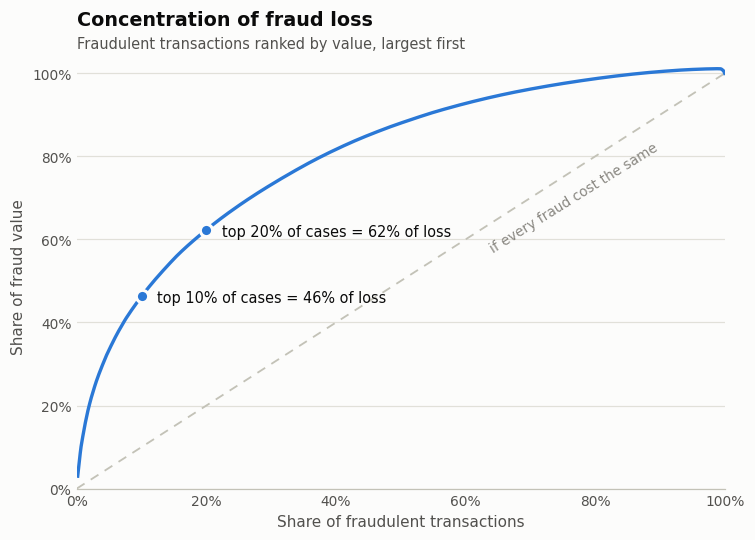

top    5% of fraud cases  ->  33.5% of fraud value
top   10% of fraud cases  ->  46.3% of fraud value
top   20% of fraud cases  ->  62.3% of fraud value
top   50% of fraud cases  ->  88.0% of fraud value


In [37]:
fraud_amts = np.sort(
    feat_df.filter(F.col("is_fraud") == 1).select("amt").toPandas()["amt"].values
)[::-1]
cum_share = np.cumsum(fraud_amts) / fraud_amts.sum()
txn_share = np.arange(1, len(fraud_amts) + 1) / len(fraud_amts)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.plot([0, 1], [0, 1], color=vz.INK["axis"], linewidth=1.2, linestyle=(0, (5, 4)))
ax.annotate("if every fraud cost the same", xy=(0.62, 0.62), xytext=(6, -14),
            textcoords="offset points", fontsize=9, color=vz.INK["muted"], rotation=32)
ax.plot(txn_share, cum_share, color=vz.CATEGORICAL[0], linewidth=2.2)

for mark in (0.10, 0.20):
    i = max(int(mark * len(fraud_amts)) - 1, 0)
    ax.plot([mark], [cum_share[i]], marker="o", markersize=8,
            color=vz.CATEGORICAL[0], markeredgecolor=vz.INK["surface"], markeredgewidth=2, zorder=5)
    ax.annotate(f"top {mark:.0%} of cases = {cum_share[i]:.0%} of loss",
                xy=(mark, cum_share[i]), xytext=(10, -4), textcoords="offset points",
                fontsize=9.5, color=vz.INK["primary"])

ax.set_title("Concentration of fraud loss")
vz.subtitle(ax, "Fraudulent transactions ranked by value, largest first")
ax.set_xlabel("Share of fraudulent transactions")
ax.set_ylabel("Share of fraud value")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
vz.strip_x_grid(ax)

vz.save(fig, "08_loss_concentration")
plt.show()

for mark in (0.05, 0.10, 0.20, 0.50):
    i = max(int(mark * len(fraud_amts)) - 1, 0)
    print(f"top {mark:>5.0%} of fraud cases  ->  {cum_share[i]:.1%} of fraud value")


**Finding.** Loss is heavily concentrated: a small minority of fraudulent transactions accounts for
the majority of the money lost.

This reframes the whole detection problem. A team measured on *case count* will optimise recall
across all fraud equally; a team measured on *dollars recovered* should put its scarce manual-review
capacity almost entirely on high-value cases, where the same review effort returns several times the
value. It also means a model tuned on plain accuracy is tuned on the wrong objective — the loss
function should be value-weighted.


---
## 8. Persisting the outputs

Four outputs, written as Parquet — columnar, compressed, and schema-carrying, so the next reader gets
real types instead of re-parsing strings.

The analytics table is **partitioned by transaction date**. Partitioning matches how the table is
actually queried (nearly always over a date range) and lets Spark skip whole directories rather than
reading the full history. It is deliberately *not* partitioned by anything high-cardinality: a
partition per merchant would create tens of thousands of tiny files and make everything slower.


In [ ]:
import shutil

def write_parquet(frame, name, partition_by=None):
    path = f"{CURATED_DIR}/{name}"
    shutil.rmtree(path, ignore_errors=True)
    writer = frame.write.mode("overwrite")
    if partition_by:
        writer = writer.partitionBy(partition_by)
    writer.parquet(path)
    return path


# Arrays and timestamps survive Parquet fine; dq_flags stays an array column.
outputs = {
    # Silver and gold are both written: same 26-column schema, different
    # precision, different audience. Two tables is what gives access control
    # something to grant separately.
    "curated_transactions": write_parquet(silver_df, "curated_transactions"),
    "analytics_transactions": write_parquet(feat_df, "analytics_transactions", "local_date"),
    "quarantine_failed_rules": write_parquet(reject_df.drop("local_ts"), "quarantine_failed_rules"),
    "dq_rule_counts": write_parquet(spark.createDataFrame(flag_counts), "dq_rule_counts"),
}

if n_corrupt:
    outputs["quarantine_unparseable"] = write_parquet(quarantine_corrupt, "quarantine_unparseable")

for name, path in outputs.items():
    print(f"{name:<26} -> {path}")

# Read one back to prove the round trip preserves types rather than assuming it.
rt = spark.read.parquet(outputs["analytics_transactions"])
print(f"\nre-read {rt.count():,} rows")
print("timestamp type preserved:", dict(rt.dtypes)["trans_date_trans_time"])
print("array type preserved   :", dict(rt.dtypes)["dq_flags"])

---
## 9. Summary

### What the data says

1. **Fraud runs on the local clock.** The rate is several times higher between 22:00 and 03:59
   UTC+8, uniformly across every day of the week, in the window where transaction volume is lowest.
   Time-of-day-aware thresholds are close to free: the strictest rules fall where the fewest genuine
   customers are transacting.
2. **Rate and value rank categories differently.** Card-not-present categories lead on fraud rate;
   high-ticket categories like travel lead on fraud value. Which list matters depends on whether the
   objective is case count or dollars.
3. **Amount alone cannot separate fraud.** The distributions overlap through the bulk of both
   populations and only separate in the tail. Amount is a component of a composite signal, not a
   threshold.
4. **Distance from home and merchant tenure are both strong, and both are engineered.** Neither
   exists as a column in the feed. Merchant tenure in particular suggests a control with no model
   attached: a probation period for newly registered merchants.
5. **Loss is concentrated in a small minority of cases.** Review capacity and model objectives should
   both be value-weighted rather than count-weighted.

### What was done to the data, in one paragraph

Read as text with the structure inferred but every type discarded; corrupt lines quarantined
separately; nesting flattened generically and mapped to the 26 required columns by leaf name; every
column cast explicitly with a named failure flag; three heterogeneous time encodings resolved to a
single instant and rendered in UTC+8 with a stated assumption about naive strings; names parsed
through eight documented branches with a quality grade per row; rows split into clean and quarantined
by a severity policy that lives in one list; direct identifiers masked or HMAC-tokenised **in place** and
quasi-identifiers generalised **in place** one layer later, so all 26 required columns survive with
only their precision reduced; four features engineered; outputs written as partitioned Parquet.

### What I would do next, and what I would not claim

**Next:**

- **Move the rules out of the notebook.** Every `flag(...)` here is a declarative assertion and
  belongs in a test framework (Great Expectations, Soda, or `dbt test`) that runs on every batch and
  fails the pipeline on a threshold breach, rather than in a notebook someone has to open.
- **Alert on the quarantine rate, not just record it.** A sudden jump in `TS_UNPARSEABLE` is an
  upstream deployment, and it should page somebody the same day rather than surface in a review.
- **Version the PII tokens.** A `token_version` column alongside each token makes key rotation
  survivable; without it, rotating the key silently breaks every join to a previously published extract.
- **Bring in external data,** as the brief encourages: BIN → issuer/country tables to test
  cross-border risk, merchant category benchmarks, and per-cardholder velocity features (count and
  value in the preceding hour), which are usually the strongest fraud signals of all and need a
  stateful streaming job rather than a batch window.

**What I would not claim:**

- The relationships above are **associations in a labelled historical extract**, not causes. The
  labels themselves come from a detection process that has its own biases — fraud that was never
  detected is labelled legitimate here, so every rate in this notebook is a floor, not an estimate.
- The `dd/MM` vs `MM/dd` reading in §4.1 is an assumption inferred from the sample. It is flagged per
  row and should be confirmed with the data producer rather than settled by a notebook.
- Tokenisation and generalisation reduce re-identification risk; they do not remove it. A cardholder
  with a distinctive pattern of behaviour remains findable by anyone holding a matching auxiliary
  dataset.

In [ ]:
spark.stop()
print("Spark session stopped.")
